# MeteoScreening `SWC_FF1_0.05_1` (2020-2025) from database (influxdb)

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Variable**: `SWC_FF1_0.05_1` &nbsp;&nbsp;|&nbsp;&nbsp; **Period**: 2020-2025  
**Cross-check**: the other depths of the same soil profile (`0.1`, `0.2`, `0.3`, `0.5` m) and the screened precipitation product — see *Cross-check* below  
**Derived from**: diive notebook template `DatabaseInfluxStepwiseMeteoScreening.ipynb` (version `9`, 15 Jul 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook
Download raw soil water content from the InfluxDB database, quality-screen and correct it on the **high-resolution** data, resample to 30MIN, and upload the result back to the database. Screening uses `StepwiseMeteoScreeningDb` from [diive](https://github.com/holukas/diive) (`diive/preprocessing/qaqc/meteoscreening.py`); download and upload use diive's in-house InfluxDB engine (`InfluxIO`, in `diive/core/io/db/influx`).

**Flow:** download (`InfluxIO`) → cross-check against the rest of the soil profile → screen on high-res data (`diive`) → resample to 30MIN → validate against the profile → upload.

**Outlier detection is stepwise:** run a test, inspect its preview plot, then commit it with `mscr.addflag()`. Re-run with different parameters as often as you like before committing. Run only the tests a variable actually needs. At the end all committed flags are aggregated into one overall quality flag `QCF`.

**This notebook is the pattern for the other depths.** `0.05` is only the shallowest sensor of the FF1 profile; `0.1`, `0.2`, `0.3` and `0.5` are screened by copies of this notebook. Copy it, change `DEPTH` in *User settings*, and **re-derive `REMOVE_DATES` from that depth's own evidence** — the removal windows below belong to the 5 cm sensor and must not be carried over blindly. See the closing note *Reusing this notebook for the other depths*.

> **Database access** needs the `influxdb-client` package, which this project pulls in via the **`diive[db]` extra** (declared in `pyproject.toml`). Note that diive *also* ships a `db` dependency group, but dependency groups are local to the project that declares them — `uv sync --group db` only works inside the diive repo, not from here. From this repo the extra is the only route.

## ⏱️ Timestamp convention (important)
The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`** (the stamp marks the *end* of the averaging interval). Getting the timestamp right is the one thing that must not go wrong, because the day/night split during screening — and the value written back to the DB — both depend on it.

The single knob is `TIMEZONE_OFFSET_TO_UTC_HOURS` (set in *User settings*). It is applied **identically** on download and on upload. Here is the full round-trip, all handled for you:

| Stage | Timezone | Convention | Done by |
|---|---|---|---|
| Database | UTC | `TIMESTAMP_END` | InfluxDB |
| After `dbc.download(..., timezone_offset_to_utc_hours=N)` | local (UTC+N) | `TIMESTAMP_END` | InfluxIO |
| During screening | local | `TIMESTAMP_MIDDLE` (converted internally) | `StepwiseMeteoScreeningDb` |
| After `mscr.resample()` | local | back to `TIMESTAMP_END` | diive |
| After `dbc.upload_singlevar(..., timezone_offset_to_utc_hours=N)` | UTC | `TIMESTAMP_END` | InfluxIO |

So screening runs on correct local middle-of-period timestamps, and the resampled value lands on the correct UTC end-of-period stamp in the DB. **`TIMEZONE_OFFSET_TO_UTC_HOURS` must match the timezone the raw data was logged in** (e.g. `1` for CET winter time) and must be the same value everywhere. This notebook prints the timestamps right after download and right after the verification download so you can confirm they look correct.

Everything in the *Cross-check* section works on `TIMESTAMP_END` as downloaded. The precipitation product read there is stored on `TIMESTAMP_MID` and is shifted to `TIMESTAMP_END` before use.

## ✏️ User settings (please adjust)

Adjust these before running. What each setting means:

**Site**
- `SITE`, `SITE_LAT`, `SITE_LON`: site ID and coordinates. The coordinates set the day/night split used during screening (not used for soil moisture — see *Outlier detection*).

**Variable to screen**
- `PROFILE`, `DEPTH`, `REPL`: the sensor's position tags. `FIELD` is assembled from them and is the InfluxDB `_field`. **This is the only place to change when screening another depth.**
- `MEASUREMENT`: exactly **one** measurement grouping the variables — `SWC` for soil water content.
- `COMPANION_DEPTHS`: the other depths of the same profile, used as the cross-check reference. They are *not* screened here.

**Time range to screen**
- `START`: first timestamp to screen — **is** included.
- `STOP`: upper bound — **is not** included.

**Data settings**
- `TIMEZONE_OFFSET_TO_UTC_HOURS`: the critical timestamp knob — see the *Timestamp convention* section above. Must match how the raw data was logged (e.g. `1` for CET winter time).
- `DATA_VERSION`: the source data version in the database (`raw`).
- `DIRCONF`: local folder holding the database connection config.

**Resampling**
- `RESAMPLING_FREQ`: the screened high-res data is resampled to this frequency.
- `RESAMPLING_AGG`: aggregation used when resampling. Soil water content is a **state**, so `'mean'` — never `'sum'`.

**Cross-check**
- `PROFILE_PRODUCT`: the raw FF1 profile file, holding all five depths of the profile. The companion columns of the cross-check are read from it instead of being downloaded again — the same five raw series were previously pulled once per depth notebook. Produced by [`SWC_FF1_PROFILE_2020-2025.ipynb`](SWC_FF1_PROFILE_2020-2025.ipynb). The screened variable is *not* read from it: it comes from the database download, which is where the tags screening needs live.
- `PREC_PRODUCT` / `PREC_COL`: the screened precipitation product, used to test whether the sensor still *responds* to rain. Produced by [`30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb`](../../30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb).
- `FIELDBOOK`: the GIN fieldbook export, read directly here so that every candidate period is adjudicated against the site record in the notebook rather than by hand.

**Parameter help**
- `SHOW_PARAM_HELP`: set `True` to print the full docstring (all parameters) of each screening method right before it runs. Leave `False` for a clean, concise notebook.

In [1]:
# --- Site ---
SITE = 'ch-lae'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# --- Variable to screen ---
# Verified 21 Jul 2026 against measurement SWC of bucket ch-lae_raw: the FF1 profile
# holds five depths (0.05, 0.1, 0.2, 0.3, 0.5), all TEROS 12, all starting
# 2020-04-10. (The older M5 profile, SWC_M5_*, ends the same day and is a
# different, now-trashed sensor set - see the closing note. The FF3 profile
# starts only in 2026 and is out of scope here.)
PROFILE = 'FF1'  # horizontal position (soil profile)
DEPTH = '0.05'  # <-- the only setting to change when screening another depth
REPL = '1'  # replicate
FIELD = f'SWC_{PROFILE}_{DEPTH}_{REPL}'
FIELDS = [FIELD]  # StepwiseMeteoScreeningDb expects a list
MEASUREMENT = 'SWC'

# The rest of the profile: the cross-check reference. Screened by their own notebooks.
COMPANION_DEPTHS = ['0.05', '0.1', '0.2', '0.3', '0.5']
COMPANION_FIELDS = [f'SWC_{PROFILE}_{d}_{REPL}' for d in COMPANION_DEPTHS if d != DEPTH]

# --- Time range to screen ---
# Raw resolution is 10MIN until the 2021 logger rebuild and 1MIN after, so this
# range is ~2.5 million records (~3 min to download). The profile starts
# 2020-04-10; asking for 2020-01-01 simply starts at the first record.
START = '2020-01-01 00:00:01'  # included
STOP = '2026-01-01 00:00:01'  # not included

# --- Data settings ---
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET, winter time). Must match how the raw data was logged.
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'

# --- Resampling ---
RESAMPLING_FREQ = '30min'  # screened high-res data is resampled to this frequency
RESAMPLING_AGG = 'mean'  # (!) soil water content is a state variable, never summed

# --- Cross-check: the raw FF1 profile, downloaded once by SWC_FF1_PROFILE_2020-2025.ipynb ---
# The companion depths are read from this file instead of being downloaded again - the same
# five raw series were previously pulled separately by every depth's notebook. The screened
# variable itself is NOT read from here: it still comes from the database download below,
# because screening needs the database tags that this values-only file does not carry.
PROFILE_PRODUCT = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
                   r'\workflow\10_METEO\20_SCREENING\SWC'
                   r'\SWC_FF1_PROFILE_RAW_2020-2025.parquet')

# --- Cross-check: the screened precipitation product (30_PRODUCTS/08) ---
PREC_PRODUCT = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
                r'\workflow\10_METEO\30_PRODUCTS'
                r'\08_METEO_PREC_GAPFILLED_2004-2025.parquet')
PREC_COL = 'PREC_TOT_T1_47_1'

# --- Cross-check: the GIN fieldbook export (site record) ---
FIELDBOOK = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
             r'\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv')

# --- Physical range of soil water content at this site, in % (volumetric) ---
# Used by the absolute-limits test and by the candidate scan. 0 is the hard
# physical floor; 60 sits above any plausible porosity for this soil and is
# far above the highest value ever measured in this profile (40.6%).
SWC_MIN, SWC_MAX = 0, 60

# --- Parameter help ---
SHOW_PARAM_HELP = False

## 🤖 Auto settings

### Buckets (do not adjust)

In [2]:
BUCKET_RAW = f'{SITE}_raw'  # source bucket, e.g. 'ch-lae_raw'
BUCKET_PROCESSED = f'{SITE}_processed'  # destination bucket, e.g. 'ch-lae_processed'
print(f'Screening variable:            {FIELD}')
print(f'Cross-check against:           {COMPANION_FIELDS}')
print(f'Source bucket (raw data):      {BUCKET_RAW}')
print(f'Destination bucket (processed): {BUCKET_PROCESSED}')

Screening variable:            SWC_FF1_0.05_1
Cross-check against:           ['SWC_FF1_0.1_1', 'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1']
Source bucket (raw data):      ch-lae_raw
Destination bucket (processed): ch-lae_processed


### Imports

In [3]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import diive as dv
from diive.core.io.db.influx import InfluxIO  # needs influxdb-client, via the diive[db] extra
from diive.core.times.times import detect_freq_groups  # the same grouping the screening uses internally

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive v{importlib.metadata.version('diive')}")

Last run: 2026-07-22 15:20:11
diive v0.91.0


## ⬇️ Download data from database

### Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

Optional — list all fields available in the measurement (does not check the selected time range):

In [5]:
display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

> Fields in measurement SWC of bucket ch-lae_raw:

> Found 16 fields in measurement SWC of bucket ch-lae_raw.

['SWC_FF1_0.05_1',
 'SWC_FF1_0.1_1',
 'SWC_FF1_0.2_1',
 'SWC_FF1_0.3_1',
 'SWC_FF1_0.5_1',
 'SWC_FF3_0.05_1',
 'SWC_FF3_0.05_2',
 'SWC_FF3_0.1_1',
 'SWC_FF3_0.2_1',
 'SWC_FF3_0.3_1',
 'SWC_FF3_0.4_1',
 'SWC_FF3_0.5_1',
 'SWC_M5_0.05_1',
 'SWC_M5_0.1_1',
 'SWC_M5_0.2_1',
 'SWC_M5_0.3_1']

### Download
Returns three objects:
- `data_simple`: high-res time series, one column per variable (nice to look at).
- `data_detailed`: dict `{varname: DataFrame}` with each variable's time series **and its database tags** — this is what the screening consumes.
- `assigned_measurements`: the auto-detected measurement per variable (a sanity check).

In [6]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

> DOWNLOADING from bucket ch-lae_raw: variables ['SWC_FF1_0.05_1'] from measurements ['SWC'], data
version ['raw'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 42 s
Wall time: 58.4 s


### Inspect downloaded data

In [7]:
data_simple

,SWC_FF1_0.05_1
TIMESTAMP_END,
2020-04-10 15:00:00,30.90000
2020-04-10 15:10:00,30.90000
2020-04-10 15:20:00,30.90000
2020-04-10 15:30:00,30.90000
2020-04-10 15:40:00,30.90000
...,...
2025-12-31 23:56:00,29.51567
2025-12-31 23:57:00,29.54534
2025-12-31 23:58:00,29.51160


In [8]:
assigned_measurements

{'SWC_FF1_0.05_1': 'SWC'}

Drop any requested variable that has no data in this period:

In [9]:
vars_not_available = [v for v in FIELDS if v not in data_detailed.keys()]
for rem in vars_not_available:
    FIELDS.remove(rem)
    print(f'Removed {rem} from FIELDS (no data in this period).')
print(f'Data available for: {list(data_detailed.keys())}')

Data available for: ['SWC_FF1_0.05_1']


### Verify download timestamps
Confirm the timestamps look right: they should be in **local time** (UTC+`TIMEZONE_OFFSET_TO_UTC_HOURS`) and mark the **end** of each averaging interval. The DB itself stores UTC — `InfluxIO` applied the offset on download. Eyeball the first/last stamps against the `START`/`STOP` you requested.

In [10]:
for v in data_detailed.keys():
    idx = data_detailed[v].index
    print(f'{v}: index name={idx.name!r}, tz={idx.tz}, freq={idx.freqstr}')
    print(f'   first={idx[0]}   last={idx[-1]}')
print(f'\nApplied UTC offset: +{TIMEZONE_OFFSET_TO_UTC_HOURS}h (timestamps above are local time)')

SWC_FF1_0.05_1: index name='TIMESTAMP_END', tz=None, freq=None
   first=2020-04-10 15:00:00   last=2026-01-01 00:00:00

Applied UTC offset: +1h (timestamps above are local time)


### The raw record has two time resolutions
This variable is **10MIN until the March 2021 logger rebuild and 1MIN after it** (fieldbook 2021-03-24/26: the FF1 logger box was rebuilt and a new program uploaded; the sensors themselves were only reconnected, not replaced). The database keeps both eras under the same field name, so a single download returns a series whose spacing changes partway through.

`StepwiseMeteoScreeningDb` handles this itself, and it is worth knowing exactly how, because it shapes what the outlier tests see:

- it groups the records by detected resolution and **drops any group holding less than 0.2%** of the records (below, the handful of 2/3/5/6-minute stragglers from the April 2024 bus failure);
- it **upsamples the coarser era onto the finest grid**, back-filling each 10MIN value across the ten 1MIN slots it covers (the timestamp is `TIMESTAMP_END`, so the fill runs backwards);
- only then does it convert to `TIMESTAMP_MID` and start screening.

Two consequences for the tests further down: the 10MIN era arrives as **runs of ten identical values**, so any test built on *increments* sees nine zeros out of ten there and is not comparable across the two eras; and a window given in *records* covers the same wall-clock time in both eras, which is why windows below are written as `60 * 24 * ...`.

This is the single most consequential fact for the tests further down. The 10MIN era arrives as **runs of ten identical values**, so any test whose statistics are computed on *differences* sees nine zeros in every ten records there. It does not merely become less sensitive — it degenerates: the rolling median absolute deviation of a mostly-constant series is `0`, so the detection band collapses and the test flags the step boundaries instead of the outliers. The Hampel filter on the double-differenced series removes **19.4% of that era** as a result, at any `n_sigma`. The measurement is in *No spike test is used* below; the practical rule is to check any test you add **per era**, not on its total count.

In [11]:
_freqgroups = detect_freq_groups(index=data_detailed[FIELD].index)
_counts = _freqgroups.value_counts()
print(f'{"freq [s]":>10s} {"records":>10s} {"share":>8s}   first record        last record')
for _f in _counts.index:
    _ix = _freqgroups[_freqgroups == _f].index
    _share = len(_ix) / len(_freqgroups) * 100
    _kept = 'used' if _share > 0.2 else 'dropped by diive (< 0.2%)'
    print(f'{_f:10.0f} {len(_ix):10d} {_share:7.2f}%   {_ix[0]}  {_ix[-1]}   {_kept}')

  freq [s]    records    share   first record        last record
        60    2452428   97.97%   2021-03-26 15:23:00  2026-01-01 00:00:00   used
       600      50079    2.00%   2020-04-10 15:00:00  2021-03-24 09:50:00   used
       180         11    0.00%   2024-04-04 12:01:00  2024-04-08 21:12:00   dropped by diive (< 0.2%)
       120          9    0.00%   2024-04-06 03:50:00  2024-04-08 02:41:00   dropped by diive (< 0.2%)
       360          3    0.00%   2024-04-05 23:34:00  2024-04-05 23:46:00   dropped by diive (< 0.2%)
       300          3    0.00%   2024-04-09 00:01:00  2024-04-09 00:11:00   dropped by diive (< 0.2%)


### Plot downloaded high-res data

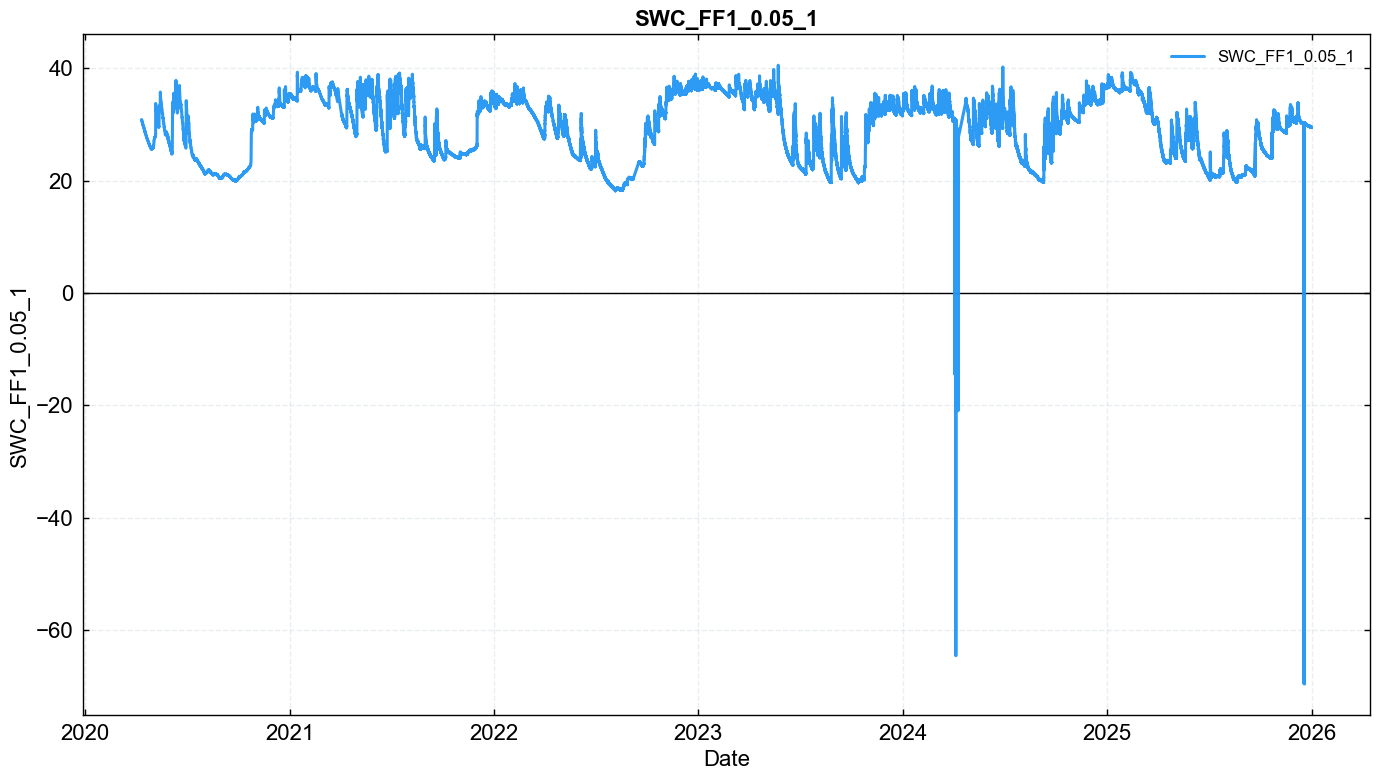

In [12]:
for varname, frame in data_detailed.items():
    dv.plotting.TimeSeries(series=frame[varname]).plot()

## 🔍 Cross-check against the rest of the soil profile
Soil water content has no external reference — no weather service measures the soil at this plot. What it does have is **four other sensors in the same profile**, 5 to 50 cm below the same square metre of forest floor, plus the site's own **precipitation** record. Together those answer the question a single soil sensor cannot answer about itself: *is it still measuring the soil?*

The two failure modes worth separating:

- **it stops reporting** — communication failures, power loss. Loud and easy: gaps and impossible values, which the screening tests below remove.
- **it stops being coupled to the soil** — the soil shrinks away from the prongs in a dry summer, a root grows into the measurement volume, the backfill settles. This one is **quiet**: the series stays inside the physical range, stays smooth, and drifts plausibly. No statistical outlier test can see it. What gives it away is that the sensor no longer *responds*: rain falls, every deeper sensor wets up, and this one does not move.

> **What this can and cannot tell you.** The depths are not replicates — a 5 cm sensor legitimately dries faster, wets first, and swings harder than a 50 cm sensor, so the levels differ and the correlations are far from 1. What is *not* legitimate is a shallow sensor sitting still while the layers underneath it wet up: water reaches 20 cm by passing through 5 cm first. Use the section to *find candidate periods*, then confirm each one against the fieldbook before putting it in `REMOVE_DATES`.

*Sources: the FF1 soil profile (this site) and the screened precipitation product of notebook `30_PRODUCTS/08`.*

In [13]:
def to_30min_mean(series: pd.Series, min_coverage: float = 0.5,
                  max_step: pd.Timedelta = pd.Timedelta('10min')) -> pd.Series:
    """Resample a high-res series to 30MIN means on the end-labelled grid.

    Uses the same end-labelled convention as the database: the period ending at T
    holds the records in (T-30min, T].

    A plain record count cannot decide whether a half hour is well covered here,
    because the raw spacing changes over the record (10MIN before the 2021 logger
    rebuild, 1MIN after) - three records mean full coverage in the first era and
    a 90% gap in the second. Each record is therefore credited with the time it
    represents, i.e. the distance back to the previous record, capped at
    *max_step* so the first record after a long gap cannot claim the whole gap.
    A half hour is returned only when the records present cover at least
    *min_coverage* of it, otherwise NaN - so a gap never masquerades as data.
    """
    if series.empty:
        raise ValueError('to_30min_mean got an empty series')
    spacing = series.index.to_series().diff()
    step = spacing.median()
    if pd.isna(step) or step > pd.Timedelta('30min'):
        raise ValueError(f'cannot resample to 30MIN from a {step} series')
    represented = spacing.clip(upper=max_step).fillna(step)
    grouper = pd.Grouper(freq='30min', label='right', closed='right')
    means = series.groupby(grouper).mean()
    coverage = represented.groupby(grouper).sum() / pd.Timedelta('30min')
    return means.where(coverage >= min_coverage)


def report_blocks(index, label: str, maxgap: str = '1D', note=None):
    """Group a DatetimeIndex of hits into contiguous blocks and print them
    ready to paste into REMOVE_DATES."""
    if len(index) == 0:
        print(f'{label}: none')
        return
    hits = pd.Series(index=pd.DatetimeIndex(index), data=1).sort_index()
    grp = (hits.index.to_series().diff() > pd.Timedelta(maxgap)).cumsum()
    print(f'{label}: {grp.nunique()} period(s)')
    for _, blk in hits.groupby(grp):
        comment = '' if note is None else f'  # {note(blk.index)}'
        print(f"    ['{blk.index[0]:%Y-%m-%d %H:%M:%S}', '{blk.index[-1]:%Y-%m-%d %H:%M:%S}'],{comment}")

#### Negative control
`to_30min_mean` would happily return a series of NaN if handed something that is not high-resolution — silently producing an "empty" comparison that looks like a data gap. Prove it raises instead.

In [14]:
for _bad, _why in [(pd.Series(dtype=float, index=pd.DatetimeIndex([])), 'empty series'),
                   (pd.Series([1.0, 2.0, 3.0],
                              index=pd.date_range('2020-01-01', periods=3, freq='1h')),
                    'already coarser than 30MIN')]:
    try:
        to_30min_mean(_bad)
    except ValueError as e:
        print(f'PASSED - {_why} raises: {e}')
    else:
        raise AssertionError(f'(!) FAILED - to_30min_mean accepted {_why}')

PASSED - empty series raises: to_30min_mean got an empty series
PASSED - already coarser than 30MIN raises: cannot resample to 30MIN from a 0 days 01:00:00 series


### Read the companion depths from the profile file
The other four depths, over the same period, are **read from the shared raw profile file** `SWC_FF1_PROFILE_RAW_2020-2025.parquet` rather than downloaded here. Every depth's notebook needs the same five raw series, so the old arrangement pulled them from the database five times over — minutes of transfer per notebook for identical data. [`SWC_FF1_PROFILE_2020-2025.ipynb`](SWC_FF1_PROFILE_2020-2025.ipynb) now downloads them once and writes that file; this cell reads it, trims it to `[START, STOP)`, and reduces the companions to 30MIN means immediately — the cross-check needs half-hourly means, not four more million-record columns in memory, so the high-resolution frame is dropped again.

> **The screened variable is not read from that file.** `SWC_FF1_0.05_1` still comes from the live database download above. `StepwiseMeteoScreeningDb` needs the database **tags** — units, gain, offset, sensor position, data version — that travel with `data_detailed`, and a values-only parquet does not carry them. The profile file is a cross-check reference only; nothing from it is screened, corrected or uploaded.

The file holds the **raw, unscreened** profile, which is what a cross-check reference has to be here (screening the reference first would paper over the very disagreements this section looks for) — but it also means the companion columns still contain their own faults. In *this* notebook the 5 cm decoupling of **2020-08-01 → 2020-10-24** is the target's own fault and is handled by `REMOVE_DATES`; in the other four depths' notebooks that same window arrives as a *companion* column and has to be masked out of the reference before it is used.

In [15]:
# The companion depths are read from the pre-downloaded profile file rather than pulled
# from the database again: they are the same five raw series in every depth's notebook,
# so downloading them once is enough. Produced by SWC_FF1_PROFILE_2020-2025.ipynb.
# The screened variable is NOT taken from here - it comes from the database download
# above, because screening needs the database tags this file does not carry.
_profile_raw = pd.read_parquet(PROFILE_PRODUCT)
assert _profile_raw.index.name == 'TIMESTAMP_END', (
    f'(!) {PROFILE_PRODUCT} is not indexed on TIMESTAMP_END')
_absent = [_v for _v in COMPANION_FIELDS if _v not in _profile_raw.columns]
assert not _absent, (
    f'(!) profile file lacks companion column(s) {_absent} - re-run SWC_FF1_PROFILE_2020-2025.ipynb')
# Trim to exactly the screened period ([START, STOP), STOP excluded) so the cross-check
# cannot silently use a wider record than the one being screened.
_profile_raw = _profile_raw.loc[(_profile_raw.index >= pd.Timestamp(START))
                                & (_profile_raw.index < pd.Timestamp(STOP))]
assert not _profile_raw.empty, (
    '(!) profile file holds no records inside [START, STOP) - is it stale?')
print(f'profile file: {_profile_raw.shape[0]} records, '
      f'{_profile_raw.index[0]} -> {_profile_raw.index[-1]}')

# Target first, then the companions ordered by depth: one 30MIN frame for the whole profile.
prof = pd.DataFrame({FIELD: to_30min_mean(data_detailed[FIELD][FIELD].dropna())})
for _v in COMPANION_FIELDS:
    _series = _profile_raw[_v].dropna()
    if _series.empty:
        print(f'(!) {_v} has no data in this period and is left out of the cross-check.')
        continue
    prof[_v] = to_30min_mean(_series)
prof = prof.sort_index()
COMPANIONS = [c for c in prof.columns if c != FIELD]

del _profile_raw  # the high-res companion frame is not needed again

assert COMPANIONS, '(!) no companion depth available - the cross-check below cannot run'
print(f'profile frame: {prof.shape[0]} half-hours, {prof.index[0]} -> {prof.index[-1]}')
print(f'target: {FIELD} | companions: {COMPANIONS}')

profile file: 2509501 records, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00
profile frame: 100387 half-hours, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00
target: SWC_FF1_0.05_1 | companions: ['SWC_FF1_0.1_1', 'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1']


### Level, coverage and correlation
First the plain description: how much data each sensor has, where it sits, and how strongly the depths move together. Correlations between depths are expected to be **high but not near-perfect** (r ≈ 0.7-0.9 on daily means) and to *decrease with depth separation* — the 5 cm and 50 cm sensors measure genuinely different things.

In [16]:
print('data coverage per year (fraction of 30MIN periods with a value):')
display(prof.notna().groupby(prof.index.year).mean().round(3))

print('\nlevel and spread over the whole period [% VWC]:')
display(prof.describe().round(2))

print('\ncorrelation of daily means:')
display(prof.resample('D').mean().corr().round(3))

data coverage per year (fraction of 30MIN periods with a value):


,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
TIMESTAMP_END,,,,,
2020,1.000,1.000,1.000,1.000,1.000
2021,0.977,0.977,0.977,0.977,0.977
2022,0.972,0.972,0.972,0.972,0.972
2023,0.998,0.998,0.998,0.998,0.998
2024,0.948,0.950,0.951,0.272,0.953
2025,1.000,1.000,1.000,0.828,1.000
2026,1.000,1.000,1.000,1.000,1.000



level and spread over the whole period [% VWC]:


,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
count,98538.00,98583.00,98585.00,83666.00,98624.00
mean,29.52,29.77,31.23,27.15,24.12
std,5.45,5.26,4.11,3.51,2.77
min,-16.90,18.20,20.37,19.91,3.96
25%,24.67,25.29,27.77,23.65,20.71
50%,30.64,31.11,32.83,28.48,25.35
75%,34.08,33.53,34.27,29.51,26.25
max,39.71,54.26,39.03,36.41,31.75



correlation of daily means:


,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
SWC_FF1_0.05_1,1.000,0.897,0.893,0.716,0.847
SWC_FF1_0.1_1,0.897,1.000,0.928,0.754,0.849
SWC_FF1_0.2_1,0.893,0.928,1.000,0.891,0.879
SWC_FF1_0.3_1,0.716,0.754,0.891,1.000,0.853
SWC_FF1_0.5_1,0.847,0.849,0.879,0.853,1.000


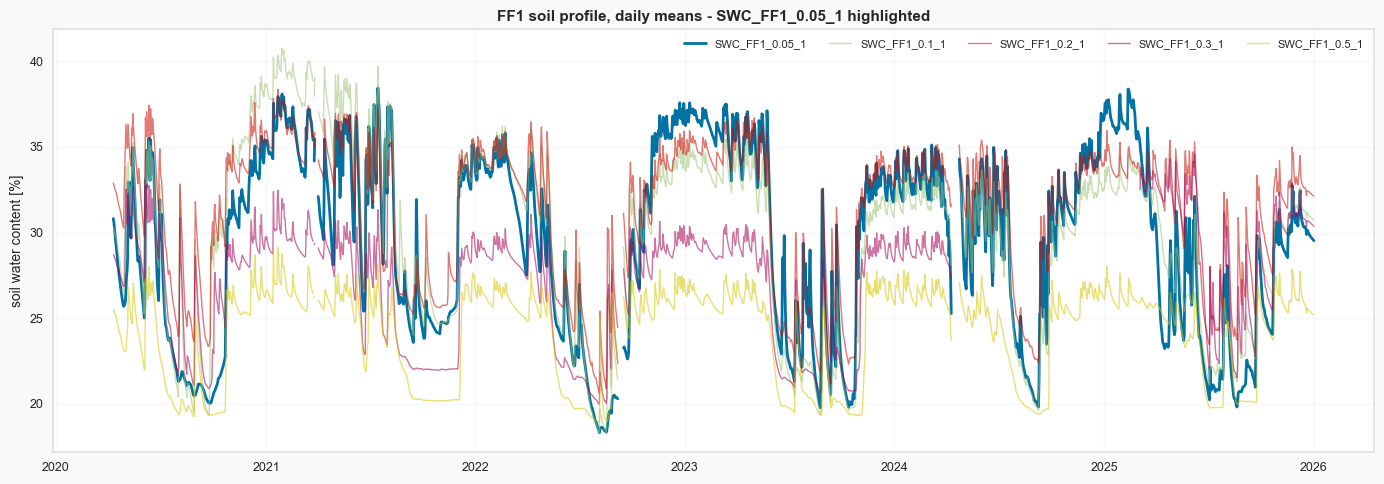

In [17]:
_daily = prof.resample('D').mean()
fig, ax = plt.subplots(figsize=(14, 5))
for _c in prof.columns:
    _lw, _alpha = (2.0, 1.0) if _c == FIELD else (1.0, .55)
    ax.plot(_daily.index, _daily[_c], label=_c, lw=_lw, alpha=_alpha)
ax.set_ylabel('soil water content [%]')
ax.set_title(f'FF1 soil profile, daily means - {FIELD} highlighted')
ax.legend(ncol=len(prof.columns), fontsize=8)
plt.tight_layout()
plt.show()

### Does the target still move with the profile?
Levels differ by depth, so compare **changes** rather than values: the daily change of the target against the daily change of the rest of the profile, correlated in a rolling 30-day window. A well-coupled sensor keeps this high (r ≈ 0.8-0.9); a sensor that has lost contact with the soil keeps producing smooth, in-range values whose *changes* have nothing to do with what the soil is doing, and the rolling correlation collapses.

This is the diagnostic that found the 2020 fault documented below — nothing in the values themselves looks wrong there.

rolling 30-day correlation of daily increments, target vs profile mean:


,count,mean,std,min,25%,50%,75%,max
TIMESTAMP_END,,,,,,,,
2020,246.0,0.57,0.37,-0.36,0.16,0.77,0.88,0.97
2021,365.0,0.82,0.14,0.38,0.74,0.87,0.92,0.99
2022,365.0,0.83,0.14,-0.06,0.76,0.86,0.93,0.99
2023,365.0,0.83,0.14,0.29,0.77,0.88,0.93,0.99
2024,343.0,0.90,0.10,0.56,0.87,0.94,0.97,0.99
2025,365.0,0.84,0.13,0.28,0.77,0.86,0.94,0.99
2026,1.0,0.96,NaN,0.96,0.96,0.96,0.96,0.96


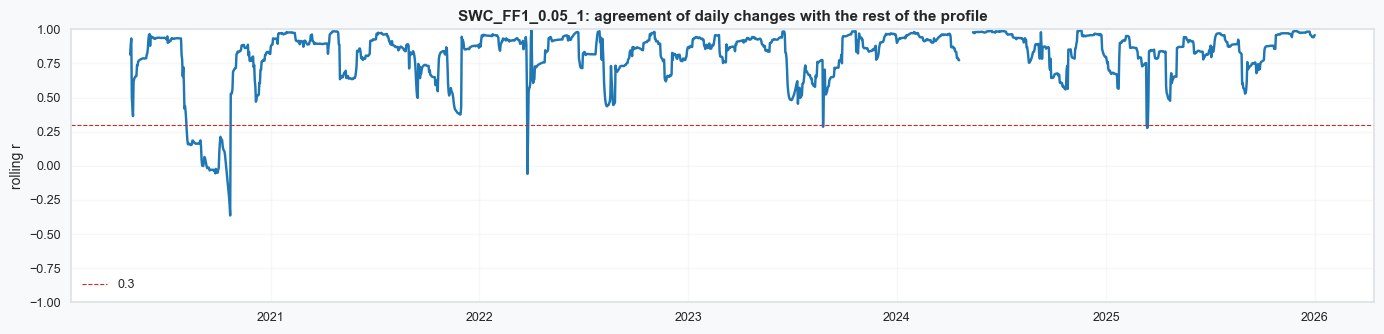

ROLLING AGREEMENT BELOW 0.3: 4 period(s)
    ['2020-08-07 00:00:00', '2020-10-22 00:00:00'],  # 77 day(s)
    ['2022-03-26 00:00:00', '2022-03-27 00:00:00'],  # 2 day(s)
    ['2023-08-25 00:00:00', '2023-08-25 00:00:00'],  # 1 day(s)
    ['2025-03-14 00:00:00', '2025-03-15 00:00:00'],  # 2 day(s)


In [18]:
_d_target = _daily[FIELD].diff()
_d_others = _daily[COMPANIONS].mean(axis=1).diff()
rollcorr = _d_target.rolling(30, min_periods=20).corr(_d_others)

print('rolling 30-day correlation of daily increments, target vs profile mean:')
display(rollcorr.groupby(rollcorr.index.year).describe().round(2))

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(rollcorr.index, rollcorr, color='tab:blue')
ax.axhline(0.3, color='tab:red', lw=.8, ls='--', label='0.3')
ax.set_ylim(-1, 1)
ax.set_ylabel('rolling r')
ax.set_title(f'{FIELD}: agreement of daily changes with the rest of the profile')
ax.legend()
plt.tight_layout()
plt.show()

report_blocks(rollcorr[rollcorr < 0.3].index, 'ROLLING AGREEMENT BELOW 0.3', maxgap='3D',
              note=lambda ix: f'{len(ix)} day(s)')

### Does the target still respond to rain?
The sharpest test for the shallowest sensor. For every day with more than 10 mm of precipitation, take the rise of each depth's daily mean over the following two days, and divide the target's rise by the profile mean's. A shallow sensor should give a **ratio at or above 1** — water arrives at 5 cm first. A ratio near **0** while the deeper sensors rise by several percent VWC is physically impossible and means the probe is no longer coupled to the soil.

The summer table is the one to read: that is when soil shrinkage opens gaps around the prongs.

In [19]:
prec = pd.read_parquet(PREC_PRODUCT)[PREC_COL]
prec.index = prec.index + pd.Timedelta('15min')  # TIMESTAMP_MID -> TIMESTAMP_END, as used here
_shared = prof.index.intersection(prec.index)
assert len(_shared) > 0.5 * len(prof), (
    '(!) precipitation product does not line up with the profile - check the timestamp shift')
print(f'precipitation: {prec.index[0]} -> {prec.index[-1]}, '
      f'{len(_shared) / len(prof) * 100:.1f}% of the profile period covered')

_dprec = prec.reindex(prof.index).resample('D').sum(min_count=40)
_events = _dprec[_dprec > 10].index

_rows = []
for _day in _events:
    _before = _daily.loc[:_day - pd.Timedelta('1D')].tail(1)
    _after = _daily.loc[_day:_day + pd.Timedelta('2D')]
    if _before.empty or _after.empty:
        continue
    _resp = _after.max() - _before.iloc[0]
    _resp['PREC'] = _dprec.loc[_day]
    _rows.append(_resp.rename(_day))
resp = pd.DataFrame(_rows)
resp['RATIO'] = resp[FIELD] / resp[COMPANIONS].mean(axis=1)
print(f'\n{len(resp)} rain events > 10 mm/day in the screened period')

print('\nmedian rise per depth [% VWC] after a > 10 mm day, per year:')
display(resp.groupby(resp.index.year).median().round(2))

print('\nmedian response ratio (target / profile mean), all events and summer only:')
_summer = resp[resp.index.month.isin([7, 8, 9, 10])]
display(pd.DataFrame({'all events': resp['RATIO'].groupby(resp.index.year).median(),
                      'Jul-Oct': _summer['RATIO'].groupby(_summer.index.year).median(),
                      'n events': resp['RATIO'].groupby(resp.index.year).size()}).round(2))

precipitation: 2004-01-01 00:30:00 -> 2026-01-01 00:00:00, 100.0% of the profile period covered

198 rain events > 10 mm/day in the screened period

median rise per depth [% VWC] after a > 10 mm day, per year:


,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1,PREC,RATIO
2020,1.16,2.95,2.11,2.06,0.69,14.4,0.77
2021,1.95,2.00,1.62,1.67,1.21,13.8,1.12
2022,1.17,1.57,1.45,1.32,1.43,13.9,0.90
2023,2.93,1.31,1.44,0.70,0.29,14.6,1.66
2024,2.32,1.73,1.92,0.94,0.59,15.5,1.70
2025,2.07,1.42,2.25,3.04,1.09,15.7,1.14



median response ratio (target / profile mean), all events and summer only:


,all events,Jul-Oct,n events
2020,0.77,0.04,20
2021,1.12,1.26,36
2022,0.90,1.50,30
2023,1.66,2.61,32
2024,1.70,1.74,39
2025,1.14,0.97,41


### Candidate periods for `REMOVE_DATES`
Four scans, each for a different failure mode. All of them produce **candidates only** — check each against the fieldbook and against the plots above before removing anything.

In [20]:
_target_hires = data_detailed[FIELD][FIELD].dropna()

report_blocks(_target_hires[(_target_hires < SWC_MIN) | (_target_hires > SWC_MAX)].index,
              f'OUTSIDE THE PHYSICAL RANGE [{SWC_MIN}, {SWC_MAX}] %', maxgap='1D',
              note=lambda ix: f'{len(ix)} record(s)')

_cov = prof[FIELD].notna().resample('D').mean()
report_blocks(_cov[_cov < 0.9].index, 'DAILY COVERAGE BELOW 90%', maxgap='2D',
              note=lambda ix: f'{len(ix)} day(s)')

report_blocks(rollcorr[rollcorr < 0.3].index, 'NOT MOVING WITH THE PROFILE (rolling r < 0.3)',
              maxgap='3D', note=lambda ix: f'{len(ix)} day(s)')

# A stuck sensor repeats one value. Runs are measured in *time*, not in records,
# because a record means ten minutes in the early era and one minute in the late one.
# Stored precision also changed: until the logger software update of 21 Apr 2020 the
# values arrived in steps of 0.1%, so during a slow dry-down they legitimately hold the
# same rounded value for hours. The threshold below is therefore loose, and the maxima
# printed with it are the more informative numbers.
_runs = (_target_hires != _target_hires.shift()).cumsum()
_spans = _target_hires.groupby(_runs).apply(lambda x: x.index[-1] - x.index[0])
_ends = _target_hires.groupby(_runs).apply(lambda x: x.index[-1])
_sizes = _target_hires.groupby(_runs).size()
_stuck = _spans[_spans >= pd.Timedelta('24h')]
print(f'IDENTICAL-VALUE RUNS LASTING >= 24 h: {len(_stuck)}')
for _g in _stuck.index:
    print(f"    ['{_ends.loc[_g] - _spans.loc[_g]:%Y-%m-%d %H:%M:%S}', "
          f"'{_ends.loc[_g]:%Y-%m-%d %H:%M:%S}'],  # {_sizes.loc[_g]} identical records")
for _label, _mask in [('whole record', _spans.notna()),
                      ('1MIN era only', _ends > pd.Timestamp('2021-03-27'))]:
    _sub = _spans[_mask]
    print(f'   longest identical-value run, {_label}: {_sub.max()} '
          f'(ending {_ends.loc[_sub.idxmax()]})')

print('\n(Copy any confirmed period into REMOVE_DATES below. Check the fieldbook first.)')

OUTSIDE THE PHYSICAL RANGE [0, 60] %: 3 period(s)
    ['2024-04-03 05:20:00', '2024-04-03 14:53:00'],  # 3 record(s)
    ['2024-04-05 06:07:00', '2024-04-09 00:20:00'],  # 17 record(s)
    ['2025-12-18 17:45:00', '2025-12-19 10:39:00'],  # 7 record(s)
DAILY COVERAGE BELOW 90%: 6 period(s)
    ['2021-03-24 00:00:00', '2021-04-02 00:00:00'],  # 10 day(s)
    ['2022-09-06 00:00:00', '2022-09-16 00:00:00'],  # 11 day(s)
    ['2023-06-15 00:00:00', '2023-06-15 00:00:00'],  # 1 day(s)
    ['2024-04-03 00:00:00', '2024-04-23 00:00:00'],  # 20 day(s)
    ['2024-06-29 00:00:00', '2024-07-01 00:00:00'],  # 3 day(s)
    ['2024-10-16 00:00:00', '2024-10-16 00:00:00'],  # 1 day(s)
NOT MOVING WITH THE PROFILE (rolling r < 0.3): 4 period(s)
    ['2020-08-07 00:00:00', '2020-10-22 00:00:00'],  # 77 day(s)
    ['2022-03-26 00:00:00', '2022-03-27 00:00:00'],  # 2 day(s)
    ['2023-08-25 00:00:00', '2023-08-25 00:00:00'],  # 1 day(s)
    ['2025-03-14 00:00:00', '2025-03-15 00:00:00'],  # 2 day(s)
IDENTIC

### Adjudicate the candidates against the fieldbook
A candidate period means nothing until it is matched against what happened at the site. The GIN
fieldbook export is read here directly, so the adjudication written up below can be re-run and
challenged rather than taken on trust.

Filtering on the SWC device tags alone would miss most of it: the entries that explain these periods
are power-supply and logger entries carrying no soil device at all. The filter therefore also takes
anything at this profile's location, its logger/DAQ, or a free-text mention of soil, power, logger
or SDI-12.

In [21]:
import html
import re
from pathlib import Path

_fb = pd.read_csv(FIELDBOOK, encoding='utf-8-sig')
_fb.columns = [c.strip() for c in _fb.columns]
_fb['date'] = pd.to_datetime(_fb['Date'], format='%d.%m.%Y', errors='coerce')
assert _fb['date'].notna().all(), '(!) unparsed dates in the fieldbook - check the date format'


# --- Fieldbook redaction --------------------------------------------------------------------
# The GIN fieldbook is also a personnel record: its entries name the people who did the work, and
# this notebook renders to a public page. Those names are replaced here, at the single point every
# fieldbook string passes through on its way to being printed - so a print site added later is
# covered without anyone having to remember it.
#
# The map lives beside the export, OUTSIDE this repository, so the repo never carries a real name.
# Its path is derived from FIELDBOOK rather than written out again, so the two cannot drift apart.
# Pseudonyms are stable and append-only, so re-running this notebook reproduces the same text.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map used to redact the fieldbook.

    Raises FileNotFoundError if the map is missing. That is the point: a missing map has to stop
    the notebook, because the alternative - carrying on with the redaction quietly disabled -
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the fieldbook redaction map is missing: {path}. Without it the names the fieldbook "
            f"records would print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()

# Longest surface form first, which is not cosmetic: the map holds both a bare surname and a
# double-barrelled one that starts with it ('Lovelace' and 'Lovelace-Byron', to use names that
# belong to nobody here), and replacing the short form first would corrupt the long one. The
# boundaries are lookarounds rather than \b because some forms end in an initial ('A. Lovelace'),
# where \b does not match. Matching is case-sensitive - these are capitalised names, and a case-insensitive pass
# would eat ordinary words.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name in a fieldbook string with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


# --- The unknown-name net ---------------------------------------------------------------------
# The map can only redact the names it already knows; this catches the ones it does not. After
# redaction, a token sitting in one of the two shapes that actually carry names - the author
# parenthesis the entries are signed with, and byline phrases such as 'with X' or 'durch X' - and
# that is neither a known technical term nor an all-caps device code is a candidate name.
#
# Both shapes were measured against the whole export before being trusted: together they leave 54
# distinct tokens on it, every one of them technical. A third shape, any capitalised pair, was
# tried and REJECTED - it leaves 560 distinct tokens, nearly all sentence starters and device
# names, which would bury the signal and train everyone to ignore the check.
#
# Candidates are never printed. An unmapped token is most likely a real name, and an exception
# message is stored in a notebook exactly like any other output - so the list is written beside
# the map and only the count is shown here.
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')
UNMAPPED_REPORT = Path(FIELDBOOK).with_name('redact_unmapped.txt')
_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
# A person is up to three capitalised words ('Ada Marie Lovelace'), and a parenthesis can list
# several of them. Matching only comma-separated single tokens was the first attempt, and it
# quietly matched almost nothing - '(Ada Lovelace)' is separated by a space, not a comma - so the
# net passed by looking at nothing at all. The positive control below is what caught that, which
# is the reason it is here rather than in a test somewhere else.
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+('
               + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Stopping here is the point: the
    alternative is that person's name printing into a page that gets published. Returns 0 so the
    call reads as a check rather than as something that produces a value.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        if write_report:
            UNMAPPED_REPORT.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {UNMAPPED_REPORT}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0

# The net is only worth having if it fires. 'Ada Lovelace' is nobody at this site, so the control
# can spell her out without disclosing anything - and it writes no report, so the real one is not
# overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print('  OK, the unknown-name net fired on a name that is not in the map')
else:
    raise AssertionError('(!) the unknown-name net did not fire on an unmapped name - it is broken.')


# The redaction is only worth having if it fires, so it is checked on a name from
# the map itself. Neither this assertion nor anything it prints may carry a real
# name, so the probe is compared against the map rather than shown.
_probe = next(iter(REDACTIONS))
assert _probe not in redact_people(f'written by {_probe}'), \
    '(!) redact_people left a mapped name in the text - the redaction is broken.'
print(f'fieldbook redaction: {len(REDACTIONS):,} surface forms loaded')


def _plaintext(s):
    """GIN stores the entry body as HTML; strip the tags and entities, and redact the names.

    Redaction happens here rather than at each print site, so that no caller can obtain the raw
    text by accident.
    """
    flat = re.sub(r'\s+', ' ',
                  html.unescape(re.sub(r'<[^>]+>', ' ', str(s))).replace('\xa0', ' ')).strip()
    return redact_people(flat)


_fb['text'] = _fb['Text'].map(_plaintext)
audit_unmapped_names(_fb['text'], 'fieldbook entries')
_mask = (_fb['Operation Tag'].astype(str).str.contains(r'SWC|iDL_FF1|iDAQ_FF1', case=False, na=False)
         | _fb['Location'].astype(str).str.contains(PROFILE, case=False, na=False)
         | _fb['text'].str.contains(r'soil|SWC|Teros|SDI|power|logger', case=False, na=False))
fb = (_fb[_mask & _fb['date'].between(START, STOP)]
      .drop_duplicates(subset=['date', 'Event Tag', 'Text'])
      .sort_values('date'))
assert len(fb) > 0, '(!) no fieldbook entries matched - has the export format changed?'
print(f'fieldbook: {len(_fb)} entries total, '
      f'{len(fb)} relevant to {PROFILE} within the screened period')


def fieldbook_near(start, stop=None, days: int = 3, maxchars: int = 220):
    """Print the fieldbook entries within *days* of a period."""
    start = pd.Timestamp(start)
    stop = pd.Timestamp(stop) if stop is not None else start
    hits = fb[fb['date'].between(start - pd.Timedelta(days=days), stop + pd.Timedelta(days=days))]
    if hits.empty:
        print(f'   (no fieldbook entry within +/-{days} days)')
        return
    for _, r in hits.iterrows():
        print(f"   {r['date']:%Y-%m-%d} {r['Event Tag']:<12s} {r['text'][:maxchars]}")

fieldbook: 2102 entries total, 129 relevant to FF1 within the screened period


In [22]:
# One entry per candidate period found by the scans above. Keep this list in sync with
# them when re-running for another depth - it is the record of what was adjudicated.
CANDIDATES = [
    ('2020-08-01', '2020-10-24', 'no response to rain (decoupled probe)'),
    ('2021-03-24', '2021-04-02', 'coverage gap'),
    ('2022-09-06', '2022-09-16', 'coverage gap'),
    ('2023-06-15', '2023-06-15', 'coverage gap'),
    ('2024-04-03', '2024-04-23', 'coverage gap + out-of-range values'),
    ('2024-06-29', '2024-07-01', 'coverage gap'),
    ('2024-10-16', '2024-10-16', 'coverage gap'),
    ('2025-12-18', '2025-12-19', 'out-of-range values'),
]
for _start, _stop, _why in CANDIDATES:
    print(f'\n--- {_start} -> {_stop}  ({_why})')
    fieldbook_near(_start, _stop, days=3)


--- 2020-08-01 -> 2020-10-24  (no response to rain (decoupled probe))
   2020-10-20 CLEAN        Cleaned the logger box for the iDL_T1_47_1 from millions of alive and death flies and leftovers from wild bees nest. Checked the box for leakage where all these animals could gotten into the box and sealed open cable fee

--- 2021-03-24 -> 2021-04-02  (coverage gap)
   2021-03-24 HW_MOD       Installed new box with datalogger und multiplexer
   2021-03-24 TRASHED      Device trashed
   2021-03-24 HW_MOD       Shutdown the FF1 logger and all components for reconstruction of the logger box. We kept the naming of all variable where we didn't replaced the sensors by new sensor (type). Since we never added the location "box" to th
   2021-03-24 ADD          Added new device to site. The sensor is installed right besides the Soil Heat Flux plate G_FF1_0.05_1
   2021-03-24 ADD          Added new device to site. The sensor is installed right besides the Soil Heat Flux plate G_FF1_0.05_2
   2021-03

#### How to read the candidate list

The outcome for `SWC_FF1_0.05_1`, read off the cell above:

- **Out of physical range** — 27 records, all of them isolated single-minute negative values
  (−14.4, −19.8, −20.9, −64.6, −69.6 …), never a run. They appear on the other depths at the same
  minutes with their own fixed negative values, which is what a failed SDI-12 read looks like once
  it has been pushed through each sensor's own calibration. The fieldbook explains why it is a fixed
  number rather than a gap: on 2020-04-10, when this profile was first logged, the technician
  considered updating the CR1000 firmware because *"firmware from S29 on provide NAN support on all
  the elements of array when measuring SDI12"* and decided against it. Without NaN support a failed
  read is stored as a number. The two clusters are both documented — the April 2024 bus failure and
  the two remote logger-program uploads on 18 and 19 Dec 2025 (the affected hours also hold 35-58
  records instead of 60). They are removed **without hand-adjudication**, and by two mechanisms rather
  than one: 20 of the 27 sit in the stray 2/3/5/6-minute frequency groups that the April 2024 bus
  failure produced, so diive discards them together with those groups before screening starts, and
  the remaining 7 are removed by the **absolute-limits test**. Either way the rule is physical and
  needs no adjudication. Removing them costs no half-hourly value at all: each is an isolated
  minute inside an otherwise complete half hour.
- **Coverage below 90%** — six periods. Four match documented events within ±3 days (logger rebuild,
  the 10-day FF1 power-supply failure, the one-day FF1 power incident of 15 Jun 2023, and the
  SDI-12 bus failure ended by unplugging the 0.3 m probe). The other two — 2024-06-29 → 2024-07-01
  (44 h) and 2024-10-16 (8 h) — have **no** fieldbook entry within ±3 days; the first is the *same*
  gap notebook `30_PRODUCTS/08` found in the precipitation record, so it is a station-wide outage
  rather than a soil-sensor fault. Gaps need no removal — they are already missing.
- **Not moving with the profile** — one long period, **2020-08 → 2020-10-22**, and it is a real
  fault. The fieldbook is **silent**: the only entry within three days of the whole window is the
  cleaning of the *tower* logger box on 20 Oct 2020, and the 21 entries between 15 Jun and
  15 Nov 2020 are site visits, sapflow and tower work — nothing touches the soil profile. The
  physical evidence is decisive anyway. **Removed** in `REMOVE_DATES` below.
- **Identical-value runs** — none lasting 24 h, and every run over 3 h falls in the **11 days
  between 2020-04-10 and 2020-04-21**, when values arrived in steps of exactly 0.1% (36 distinct
  values in 1543 records). That ends with the fieldbook entry of 2020-04-21, *"New datalogger
  software with two byte precision for the soil profile measurement (Teros 12 and 21)"*: from that
  afternoon on the values carry full float precision (2042 distinct values in the next 2087 records)
  and the long runs stop for good. A storage-resolution artefact, not a stuck sensor — the values
  themselves are usable, they are just coarse. In the 1MIN era no value ever repeats for more than
  five minutes, and that one case sits inside the April 2024 bus trouble.

The 2022-03, 2023-08 and 2025-03 one- and two-day dips of the rolling correlation are noise from
near-zero daily changes (dividing small differences by small differences), not faults. **Kept.**

## ▶️ Start MeteoScreening with `diive`

> Validating data for variable SWC_FF1_0.05_1 ...

> Found 6 unique frequencies across 2502533 records.

> Found frequencies:

> The following frequencies will be used: [60.0, 600.0] (seconds)

> Note that there is more than one single time resolution and all data will be upsampled to match 
the highest found time resolution (60.0S).

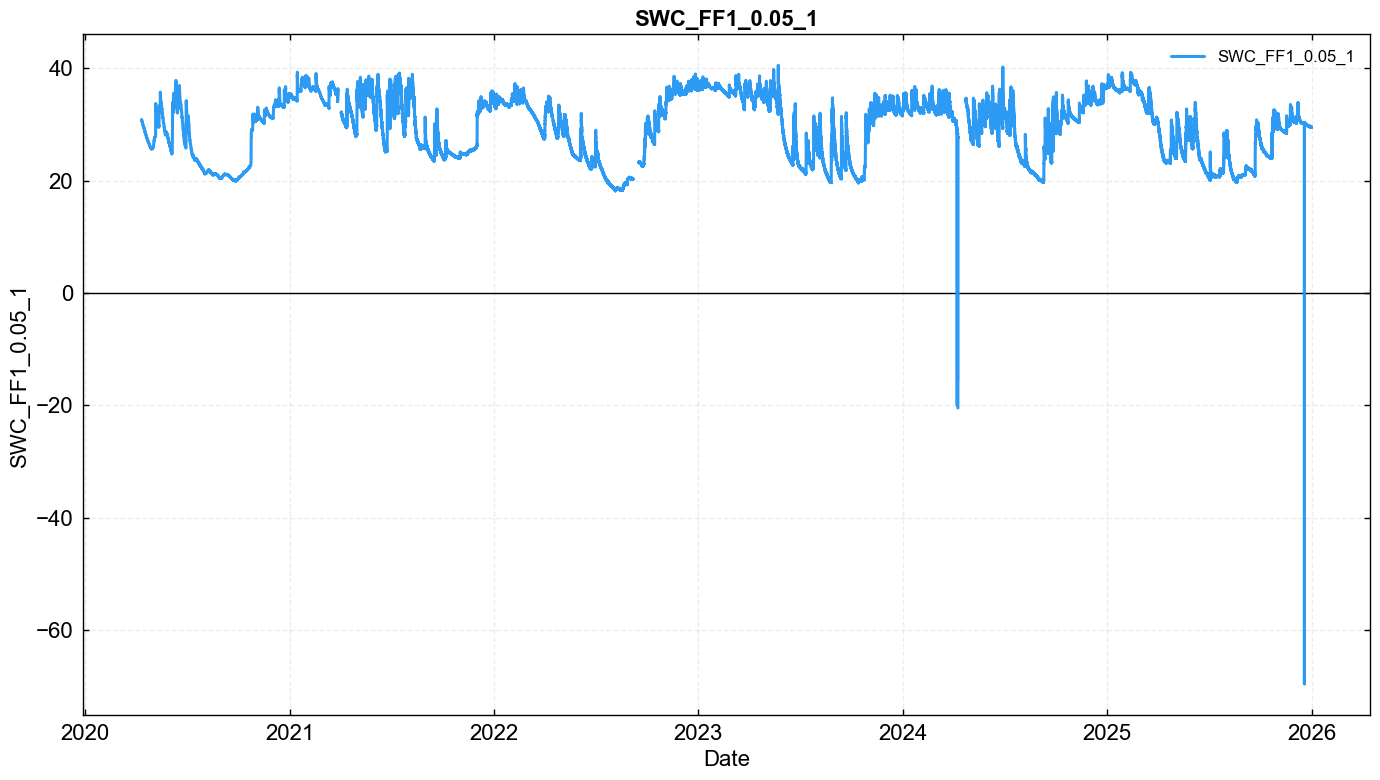

In [23]:
mscr = dv.qaqc.StepwiseMeteoScreeningDb(
    site=SITE,
    data_detailed=data_detailed,
    fields=FIELDS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
mscr.showplot_orig()

## 🔍 Outlier detection
Run a test → inspect its preview → commit with `mscr.addflag()`. Only the committed flag of the **most recent** test is added. Skip any test a variable does not need.

**What soil water content needs, and what it does not.** The series is smooth, strongly autocorrelated, and seasonally non-stationary: it ranges over more than 20 percentage points between a wet winter and a dry August, and the wet and dry extremes are the most interesting values in it, not the least trustworthy. Two consequences run through this whole section:

- **Never split day and night.** Every test below is run with `separate_daytime_nighttime=False`. Soil moisture has no meaningful diurnal cycle at these depths, so a day/night split would only halve the sample of each threshold.
- **Distribution-wide tests do not belong here.** A z-score over the whole record measures how far a value sits from the multi-year mean, which for this variable is a statement about the season, not about data quality. Those tests are listed further down, switched off, with the reasoning.

What is actually needed is short: the documented sensor fault (**manual removal**), the failed-read sentinels (**absolute limits**), and the **missing-values** flag. No spike test is committed — see *No spike test is used* below for the measurement that settles it.

In [24]:
mscr.start_outlier_detection()

> Starting step-wise outlier detection for variable SWC_FF1_0.05_1 ...

Plot the current cleaned data at any point during detection:

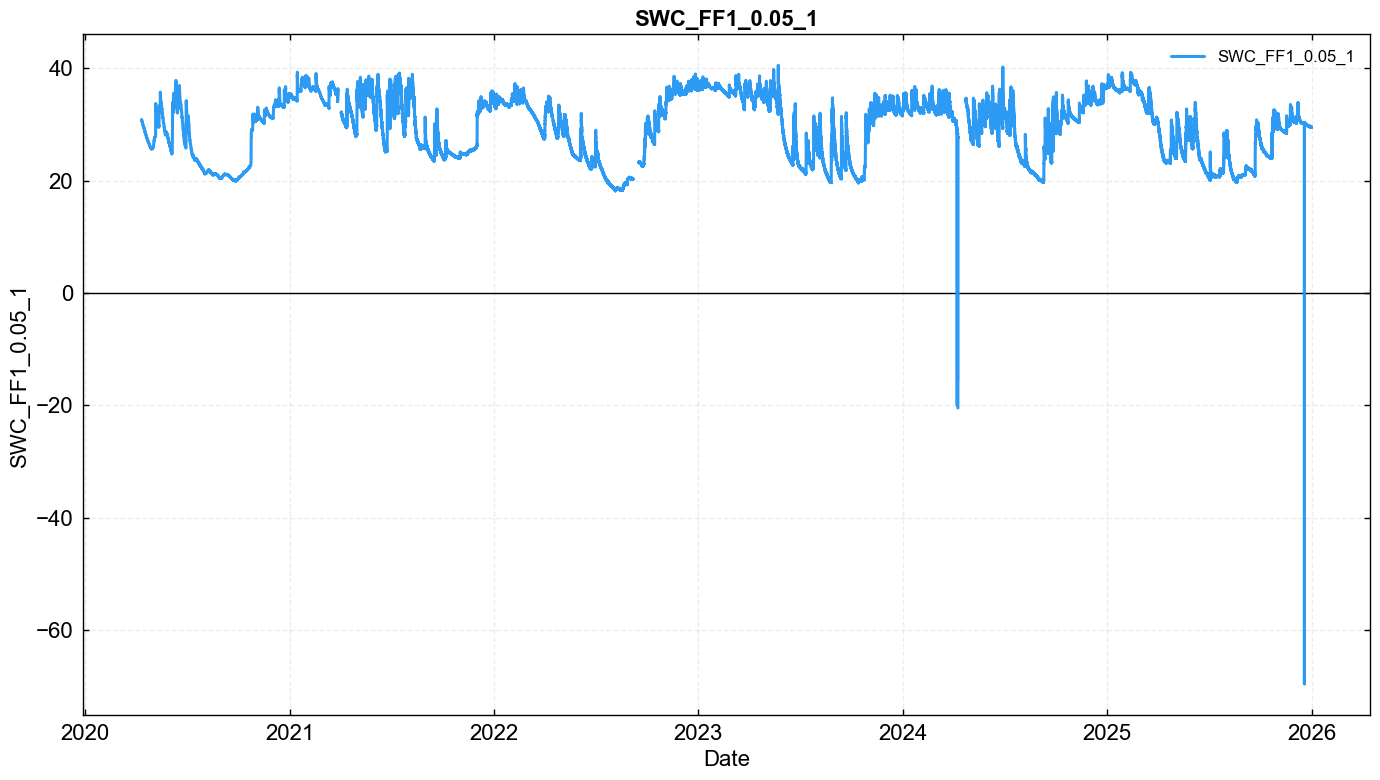

In [25]:
for key, val in mscr.outlier_detection.items():
    val.showplot_cleaned(interactive=False)

### Manual removal
Flag specific timestamps or time ranges for removal — known sensor failures, maintenance windows, etc. Give `[start, stop]` pairs and/or single timestamps.

In [26]:
if SHOW_PARAM_HELP:
    help(dv.outliers.ManualRemoval)

> running ManualRemoval ...

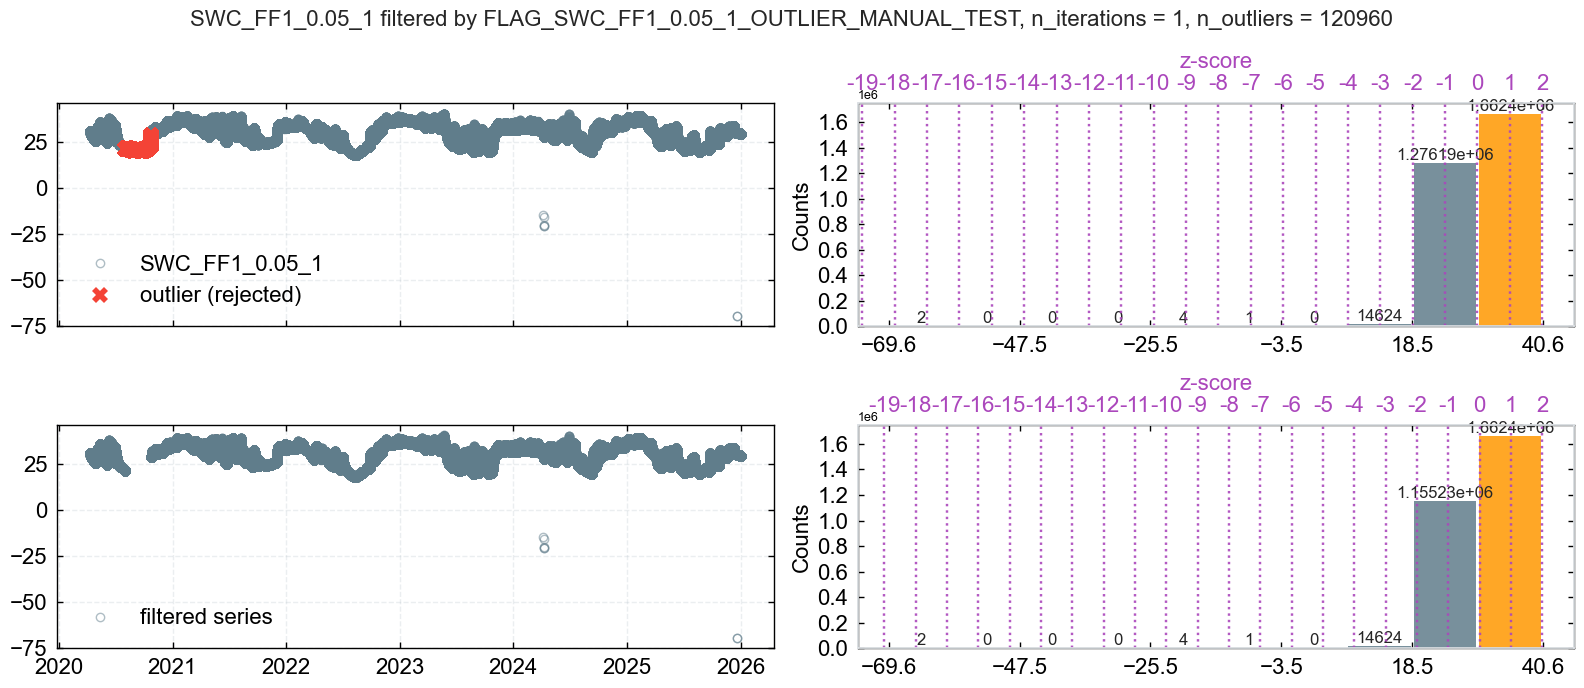

In [27]:
# Windows for THIS depth (5 cm). They are derived from this sensor's own evidence and
# must be re-derived for every other depth - see the closing note.
#
# Boundaries carry some slack on each side: screening runs internally on TIMESTAMP_MID
# while the cross-check above is on TIMESTAMP_END.
REMOVE_DATES = [
    # --- Aug-Oct 2020: the probe lost contact with the soil ------------------------
    # Not a fieldbook event and not visible in the values, which stay smooth and
    # in range the whole time. It shows up as a total loss of rain response:
    #   30 Aug 2020, 53.3 mm of rain in one day. Daily means before -> after:
    #     0.05 m  20.49 -> 20.51   (+0.02)   <- this sensor
    #     0.1 m   19.70 -> 27.07   (+7.4)
    #     0.2 m   23.84 -> 29.37   (+5.5)
    #     0.3 m   21.11 -> 27.24   (+6.1)
    #     0.5 m   19.26 -> 21.58   (+2.3)
    # Water cannot reach 50 cm without passing 5 cm. Over the whole window 242 mm of
    # rain fell and the sensor's largest single-day change was 0.18% VWC, while it
    # drifted smoothly from 20.0 to 22.7 - a probe reading its own drift in an air
    # gap, not the soil. The median summer response ratio for 2020 is 0.04 against
    # 0.97-2.61 in every other year.
    # Onset: last normal response 29 Jun 2020, first failed response 2 Aug 2020 (no
    # event > 10 mm in between, so the exact day cannot be pinned down). Recovery:
    # 23 Oct 2020, when 27 mm of rain closed the gap and the sensor jumped back onto
    # the profile within a day. Most likely the backfill settling and cracking around
    # a probe installed on 19 Mar 2020, in its first dry summer.
    # The fieldbook has nothing: no entry between 15 Jun and 15 Nov 2020 touches the
    # soil profile (see the adjudication cell above). This window rests on the physical
    # evidence alone - which is why the cross-check section exists.
    ['2020-08-01 00:00:00', '2020-10-24 00:00:00'],
]
if REMOVE_DATES:
    mscr.flag_manualremoval_test(remove_dates=REMOVE_DATES, showplot=True, verbose=True)
else:
    print('No manual removal windows for this depth - skip the addflag cell below.')

In [28]:
if REMOVE_DATES:
    mscr.addflag()

> ++Added flag column FLAG_SWC_FF1_0.05_1_OUTLIER_MANUAL_TEST to flag data

### Absolute limits
Flags values outside a fixed physical range `[minval, maxval]`. This is the workhorse test for soil water content: every artefact in this record that is *not* the 2020 decoupling is a failed sensor read, and every failed read lands far outside the physical range.

In [29]:
if SHOW_PARAM_HELP:
    help(dv.outliers.AbsoluteLimits)

> running AbsoluteLimits ...

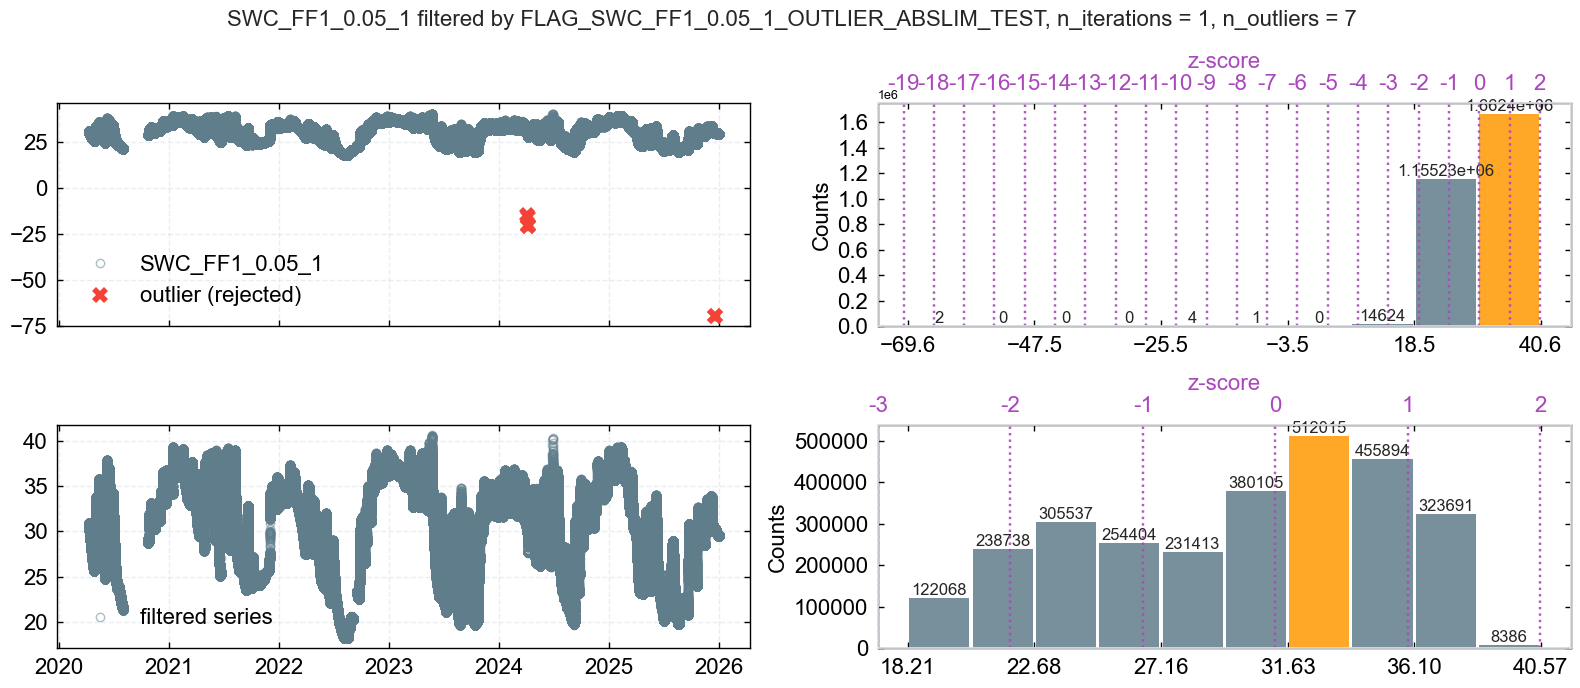

In [30]:
# Volumetric water content in %, so 0 is the hard physical floor. The upper limit is
# deliberately loose: the highest value ever recorded in this profile is 40.6%, well
# below any plausible porosity, so 60 can only fire on something unphysical.
# A failed SDI-12 read enters the record as that sensor's calibration polynomial
# evaluated at zero response, which lands at a fixed negative value per sensor
# (-14.4, -19.8, -69.6 ...) - hence a floor of 0 catches all of them and nothing else.
mscr.flag_outliers_abslim_test(minval=SWC_MIN, maxval=SWC_MAX, showplot=True, verbose=True)

In [31]:
mscr.addflag()

> ++Added flag column FLAG_SWC_FF1_0.05_1_OUTLIER_ABSLIM_TEST to flag data

### No spike test is used, and the Hampel filter must not be
Every remaining template test (Hampel, z-score, rolling z-score, local SD, increments z-score, local outlier factor, trim low) is **left switched off**, and for the Hampel filter that is not a matter of taste — measured on this record it is destructive:

| Hampel call | flagged in the 10MIN era | flagged in the 1MIN era |
|---|---|---|
| `use_differencing=True, n_sigma=8` | **97 085 (19.4%)** | 261 (0.0%) |
| `use_differencing=True, n_sigma=30` | 96 746 (19.3%) | 47 |
| `use_differencing=True, n_sigma=100` | 95 898 (19.1%) | 27 |
| `use_differencing=False, n_sigma=8` | 14 493 (2.9%) | 11 731 (0.5%) |

Raising `n_sigma` twelve-fold barely changes the count, which is the tell: the threshold is degenerate, not conservative. `use_differencing=True` runs the filter on the double-differenced series (Papale et al. 2006, a discrete curvature — *not* a simple rate of change), and in the upsampled 10MIN era nine of every ten records are identical copies. The rolling MAD of that is exactly `0`, and where a scale of zero is substituted by a tiny epsilon the detection band collapses to nothing, so every record at a ten-minute step boundary is flagged — about two in ten, hence the 19.4%.

> **Note on the diive version.** The table above is what diive did *before* the degeneracy was fixed. It now leaves records unflagged where the rolling MAD is exactly zero, instead of substituting `1e-6`, and it no longer differences across gaps (see the CHANGELOG entries for `Hampel`). Re-measured on this record with the fixed version, the same call flags **15 records in the 10MIN era instead of 97 085**, and `n_sigma` finally does something (248 → 32 → 14 records at `n_sigma` 8 → 30 → 100).
>
> **The conclusion is unchanged, and now rests on the working filter rather than the broken one:** run after absolute limits, the fixed Hampel still flags 235 records — and both wetting fronts described below are among them. It removes real soil moisture, which is exactly why no spike test is committed here.

**There is nothing for a spike test to find.** Once absolute limits has removed the 27 failed reads, the largest remaining excursions in the 1MIN era are real:

- 2023-09-13 17:01, 20.8 → 25.6% in one minute, with 18.1 mm of rain in that three-quarter hour (41.7 mm that day) — and the level is still up six hours later.
- 2024-06-21 19:46, 28.8 → 33.9%, 9.4 mm in the window, likewise sustained.

Those are wetting fronts arriving at 5 cm, the most physically real feature in the series. The 99.99th percentile of minute-to-minute change is 0.31%; the only larger jumps are these fronts and the edges of the April 2024 gap. Any filter tuned tightly enough to fire would remove the fronts.

The others, for the record: **z-score over the whole record** measures distance from the multi-year mean, which for this variable *is* the season — August 2022 and February 2021 sit at opposite ends of a 20-point range and both are correct. **Rolling z-score / local SD** fight the same physics as Hampel. **Increments z-score** degenerates in the back-filled era exactly as the differenced Hampel does. **Local outlier factor** is far too slow on 1MIN data. **Trim low** removes a fixed share of low values by construction.

So screening here is: **manual removal** (the documented fault) + **absolute limits** (physical range) + **missing values**.

One practical warning for any test you do try: differencing-based tests compute their differences **after dropping missing records**, so the records flanking every gap are compared across the gap and look like spikes. This record has a 14-day gap in April 2024 and a 10-day one in September 2022.

If you want to try one anyway, the calls are below. Run it, look at the preview, check what it does to the 2020-2021 era specifically, and only `mscr.addflag()` if it is genuinely removing artefacts.

In [32]:
# Optional, all off by default - read the note above before enabling any of these,
# and check the flagged count per era rather than the total.
# mscr.flag_outliers_hampel_test(window_length=60 * 24, n_sigma=8, use_differencing=False,
#                                separate_daytime_nighttime=False,
#                                repeat=False, showplot=True, verbose=3)
# mscr.flag_outliers_zscore_test(thres_zscore=4.5, separate_daytime_nighttime=False,
#                                repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_zscore_rolling_test(thres_zscore=4.5, winsize=60 * 24 * 7,
#                                        repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_localsd_test(n_sd=7, winsize=60 * 24 * 7, constant_sd=False,
#                                 separate_daytime_nighttime=False,
#                                 repeat=False, showplot=True, verbose=True)
# mscr.flag_outliers_increments_zcore_test(thres_zscore=40, repeat=True, showplot=True, verbose=True)
# mscr.addflag()

### Missing values
Not an outlier test — flags missing records so they are counted in the overall `QCF`.

In [33]:
mscr.flag_missingvals_test(verbose=True)

> running MissingValues ...

> MISSING VALUES TEST: Generated new flag variable FLAG_SWC_FF1_0.05_1_MISSING_TEST, newly 
calculated from variable SWC_FF1_0.05_1, with flag 0 (good values) where SWC_FF1_0.05_1 is 
available, flag 2 (bad values) where SWC_FF1_0.05_1 is missing.

### Overall quality flag QCF
Aggregate all committed test flags into one overall flag `QCF` (0 = good, 1 = marginal, 2 = bad) and filter the series. Required before corrections and resampling.

In [34]:
mscr.finalize_outlier_detection()

#### Reports

In [35]:
mscr.report_outlier_detection_qcf_evolution()

====================================================================================================
====================

QCF EVOLUTION: SEQUENTIAL TEST APPLICATION

====================================================================================================
====================

Shows how QCF flag distribution changes as tests are applied sequentially

Target variable: SWC_FF1_0.05_1

...

----------------------------------------------------------------------------------------------------
--------------------

1     SWC_FF1_0.05_1_MISSING                 0        2953218      0            100.00    0.00      
2953218/0/0

2     SWC_FF1_0.05_1_OUTLIER_MANUAL          120960   2832258      120960       95.90     4.10      
2832258/0/120960

3     SWC_FF1_0.05_1_OUTLIER_ABSLIM          7        2832251      120967       95.90     4.10      
2832251/0/120967

====================================================================================================
====================

In [36]:
mscr.report_outlier_detection_qcf_flags()

════════════════════════════════════════════════════════════════════════════════════════════════════

INDIVIDUAL TEST FLAG STATISTICS: SWC_FF1_0.05_1

════════════════════════════════════════════════════════════════════════════════════════════════════

Total test flags: 3

┌─ REPORT 1A: ALL RECORDS (INCLUDING MISSING VALUES)

...

├─ SWC_FF1_0.05_1_OUTLIER_ABSLIM

│  Period          │ Pass (0)        │ Warn (1)        │ Fail (2)        │ Missing

│  -------------------------------------------------------------------------------------

│  OVERALL         │ 2953211 (100.0%) │     0 (  0.0%)  │     7 (  0.0%)  │    0 (  0.0%)

════════════════════════════════════════════════════════════════════════════════════════════════════

In [37]:
mscr.report_outlier_detection_qcf_series()

======================================================================

QCF QUALITY CONTROL REPORT: SWC_FF1_0.05_1

======================================================================

[1] TIME PERIOD

Start:  2020-04-10 14:50

...

[4] DATA LOSS ANALYSIS

Records retained after QC: 2832251/2953218 (95.90%)

Data loss from QC:         120967/2953218 (4.10%)

Final data coverage:       2832251/3011590 (94.05% of potential)

======================================================================

#### Plots

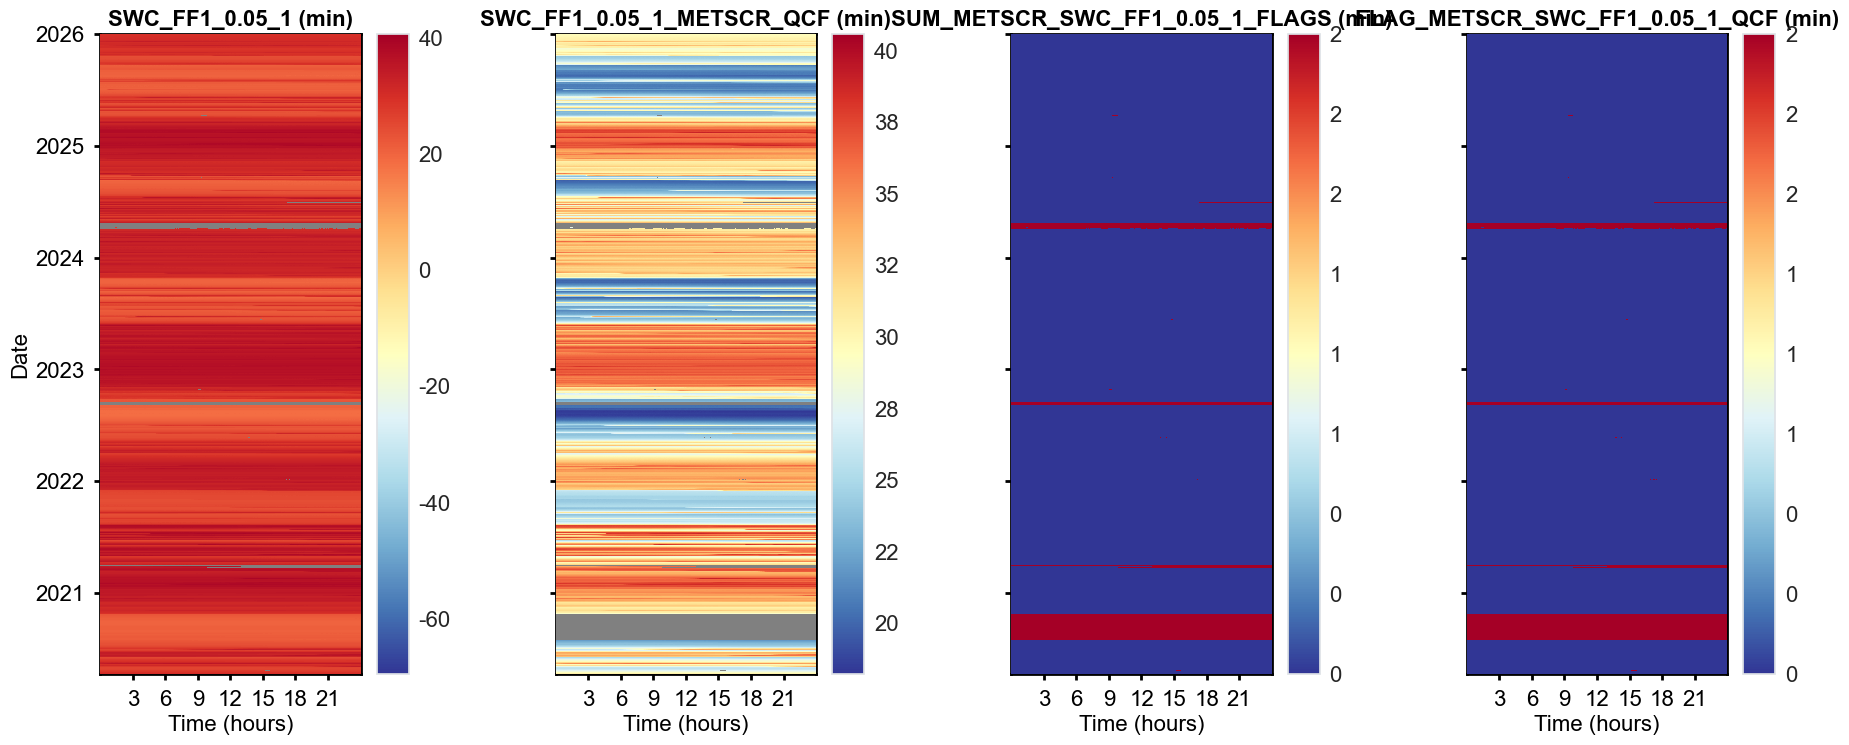

In [38]:
mscr.showplot_outlier_detection_qcf_heatmaps()
# mscr.showplot_outlier_detection_qcf_timeseries()

## 🔧 Corrections
Applied to the high-res, QCF-filtered data. **None of them apply to soil water content**, and all calls below stay commented out.

The corrections diive offers are offset removals for radiation and relative humidity, threshold clipping, and setting ranges to a constant — every one of them writes a value the sensor did not measure. For this variable there is nothing to correct *within* the series: a probe reading too high or too low is a calibration matter (soil-specific permittivity calibration), which cannot be fixed after the fact from the series itself, and the one real fault in this record was a decoupled probe, whose values are not correctable but simply wrong and already removed.

> ⚠️ In particular, do **not** clip to a minimum: the failed reads are already gone via absolute limits, and clipping would replace a missing measurement with a fabricated 0% — which reads as "bone dry soil" downstream.

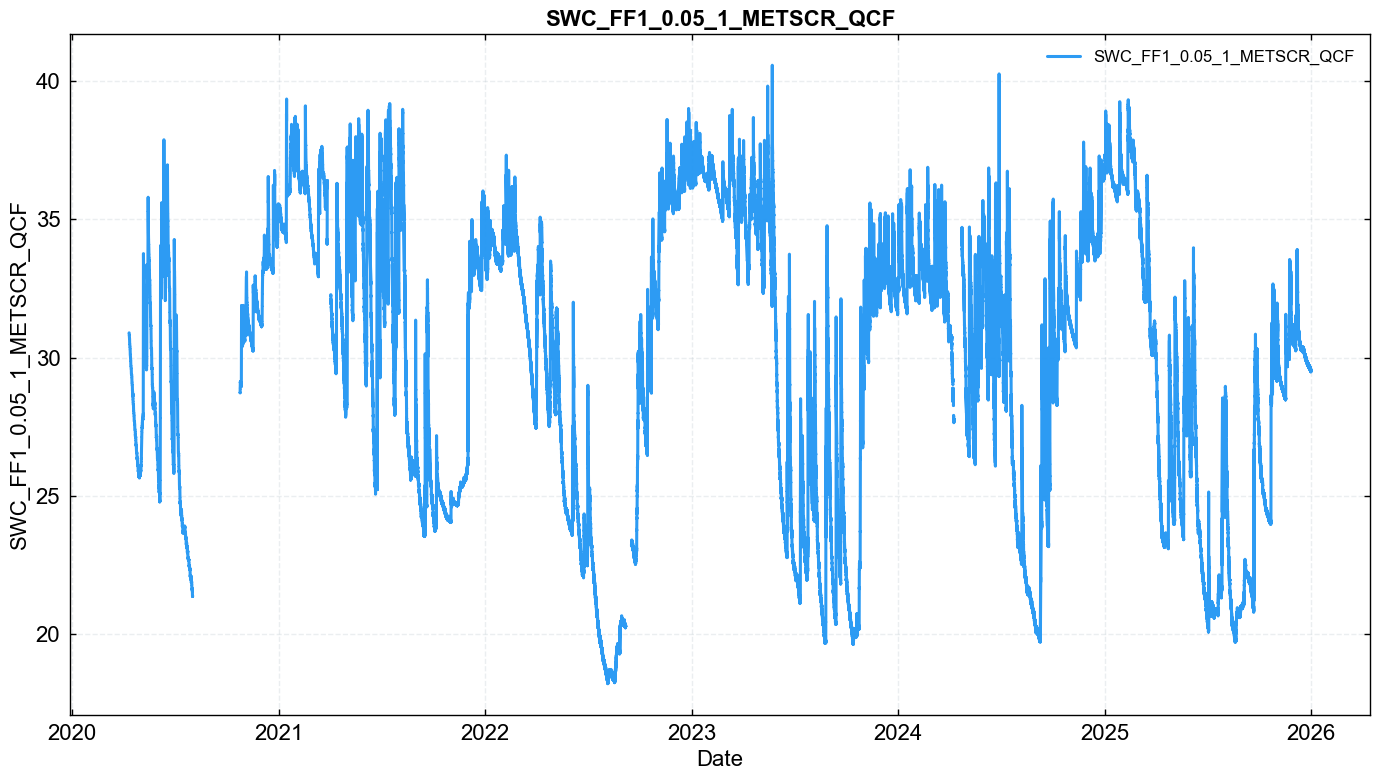

In [39]:
mscr.showplot_cleaned()

Inspect the most frequent values first (read-only, safe to run). For soil water content there should be **no** dominant repeated value: a value appearing thousands of times in the 1MIN era would mean a stuck sensor. Frequent repeats *are* expected in the 2020-2021 part, where each 10MIN reading was back-filled across ten 1MIN slots.

In [40]:
for ff in mscr.fields:
    vc = mscr.series_hires_cleaned[ff].value_counts()
    print(f'--- {ff} (top 20 of {mscr.series_hires_cleaned[ff].count()} records) ---')
    print(vc.head(20))

--- SWC_FF1_0.05_1 (top 20 of 2832251 records) ---
SWC_FF1_0.05_1_METSCR_QCF
27.4    930
28.3    837
27.7    790
29.4    770
28.0    760
29.0    680
29.7    640
28.7    610
29.6    590
30.8    563
30.4    560
30.7    510
27.6    480
30.0    470
27.9    440
30.3    431
29.3    412
29.9    400
29.1    380
28.6    370
Name: count, dtype: int64


In [41]:
# All commented out on purpose - none of these apply to soil water content.
# mscr.correction_setto_max_threshold(threshold=60)
# mscr.correction_setto_min_threshold(threshold=0)
# mscr.correction_setto_value(dates=[['2022-04-01', '2022-04-05']], value=0, verbose=1)
# mscr.correction_set_exact_value_to_missing(values=[0])
# mscr.showplot_cleaned(interactive=False)

## 🔁 Resampling

### Resample to 30MIN
Resample the screened high-res series to `RESAMPLING_FREQ`. The output timestamp is `TIMESTAMP_END` again (see *Timestamp convention*), ready for upload.

> running resample_series_to_freq ...

> Resampling data from min to 30min frequency ...

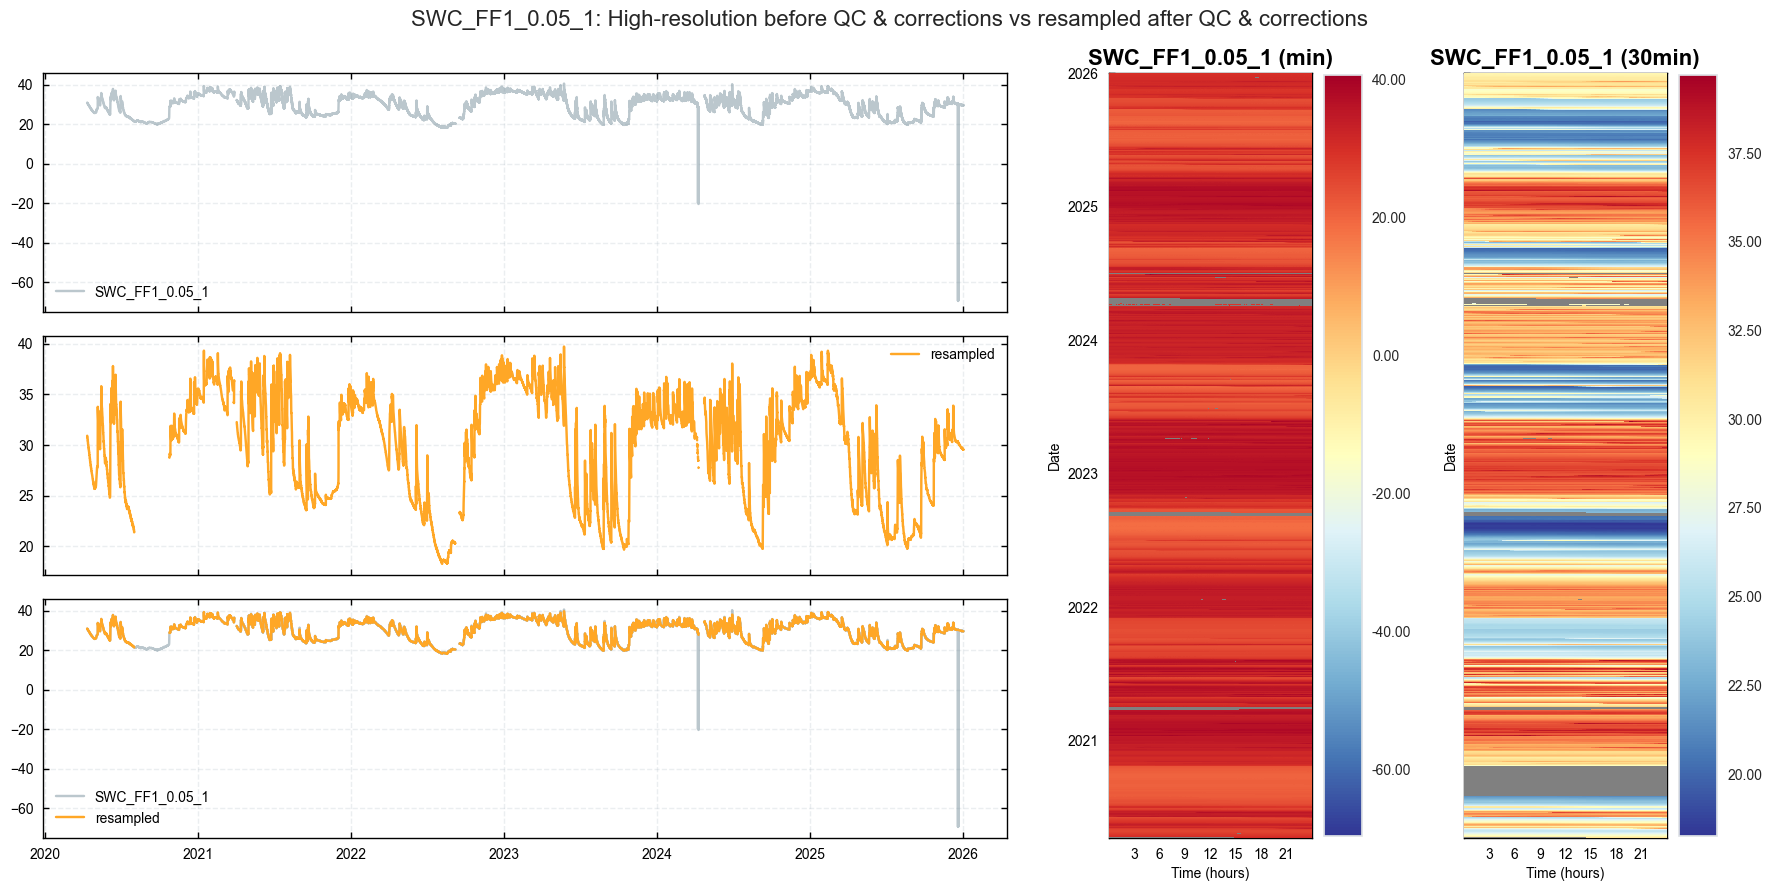

In [42]:
# mincounts_perc stays at the template default of .25, the opposite choice from the
# precipitation notebook. A 30MIN *mean* of a smooth state variable is well estimated
# from a quarter of the records, whereas a *sum* built from a quarter of the records
# under-reports by construction. Requiring near-complete coverage here would throw
# away good half-hours during the April 2024 bus trouble for no gain in accuracy.
mscr.resample(to_freqstr=RESAMPLING_FREQ, agg=RESAMPLING_AGG, mincounts_perc=.25)
mscr.showplot_resampled()

### Check the resampled time resolution

In [43]:
for v in mscr.resampled_detailed.keys():
    freq = dv.times.DetectFrequency(index=mscr.resampled_detailed[v].index, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: {freq}')

> Detect frequency: 30min (all methods agree)

PASSED - SWC_FF1_0.05_1: 30min


### Re-check the screened product against the profile
The same comparison as before screening, now on the resampled 30MIN product. Screening should leave the agreement with the rest of the profile **no worse** than it was — if the correlation drops, a test removed real soil moisture rather than an artefact. It is expected to improve slightly here, because the removed 2020 window is exactly the period in which this sensor disagreed with the profile.

In [44]:
_screened = mscr.resampled_detailed[FIELD][FIELD]

_before = prof.resample('D').mean()
_after = _before.copy()
_after[FIELD] = _screened.resample('D').mean()

r_before = _before[FIELD].diff().corr(_before[COMPANIONS].mean(axis=1).diff())
r_after = _after[FIELD].diff().corr(_after[COMPANIONS].mean(axis=1).diff())
n_before = prof[FIELD].notna().sum()
n_after = _screened.notna().sum()

print(f'{"":18s} {"n 30MIN":>9s} {"r(increments)":>15s} {"mean [%]":>10s}')
print(f'{"before screening":18s} {n_before:9d} {r_before:15.3f} {prof[FIELD].mean():10.2f}')
print(f'{"after screening":18s} {n_after:9d} {r_after:15.3f} {_screened.mean():10.2f}')
print(f'{"removed":18s} {n_before - n_after:9d} '
      f'({(1 - n_after / n_before) * 100:.2f}% of the half-hours that had a value)')

if r_after < r_before - 0.01:
    print('\n(!) WARNING - agreement with the profile got worse. A test may have removed real data.')
else:
    print('\nOK - screening did not degrade agreement with the rest of the profile.')

                     n 30MIN   r(increments)   mean [%]
before screening       98538           0.736      29.52
after screening        94462           0.772      29.88
removed                 4076 (4.14% of the half-hours that had a value)

OK - screening did not degrade agreement with the rest of the profile.


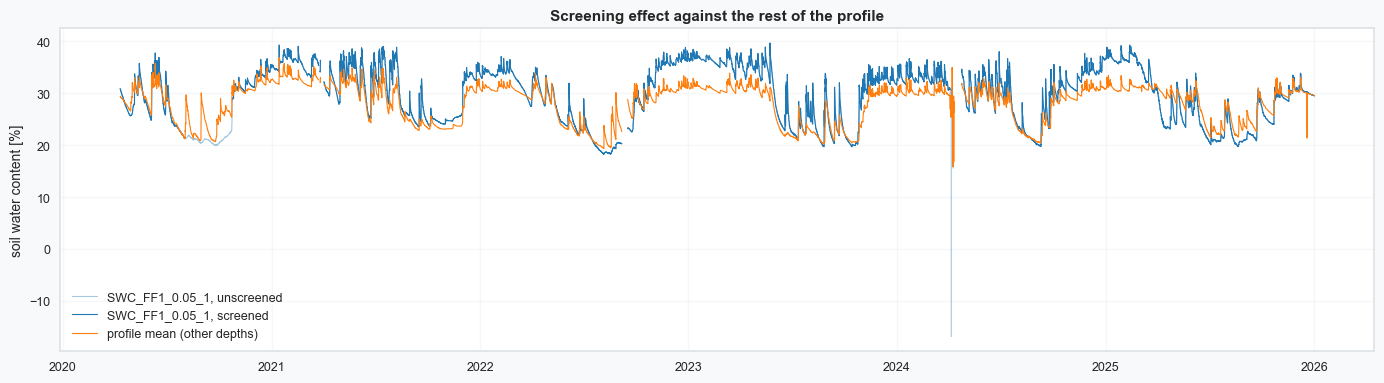

In [45]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prof.index, prof[FIELD], label=f'{FIELD}, unscreened', color='tab:blue', alpha=.4, lw=.8)
ax.plot(_screened.index, _screened, label=f'{FIELD}, screened', color='tab:blue', lw=.8)
ax.plot(prof.index, prof[COMPANIONS].mean(axis=1), label='profile mean (other depths)',
        color='tab:orange', lw=.8)
ax.set_ylabel('soil water content [%]')
ax.set_title('Screening effect against the rest of the profile')
ax.legend()
plt.tight_layout()
plt.show()

### 🧪 Audit the screening in both directions
The re-check above is one number. This section asks the two questions that number cannot answer, and
prints the evidence for each:

1. **Is everything that was removed genuinely bad?** Nothing may leave the record without a committed
   test asking for it; every absolute-limits removal must really be outside `[SWC_MIN, SWC_MAX]`;
   removing an isolated bad minute must not empty the 30MIN mean that contained it; and — the part
   that matters here and at no other depth — the **manual window must earn its place from the data**,
   not from the write-up standing next to it.
2. **Is everything real still there?** Every rain event > 10 mm/day must keep its response, and the
   agreement with the rest of the profile must not get worse.

**This is the depth that needs the audit.** It is the only one of the five with a non-empty
`REMOVE_DATES`, and that one window takes about 4% of the record, where the other four depths lose a
handful of isolated minutes (0.00-0.04%). So the first question is the real check here, and the cell
below asks it the hard way: for every committed window it prints the sensor's response ratio and its
rolling agreement *inside* the window against the record medians, on every run. If the 2020 window
ever stops looking like a decoupled probe, the notebook says so instead of leaving the claim to the
prose.

A rain event whose response disappears **because it sat inside the removal window** is counted
separately and is not damage — deleting those responses is the entire point of the window. Only an
event that loses its response *outside* any window is a failure.

> **Reading the "largest daily rise inside" line.** A response is measured from the day before an
> event to the *two days after* it, so an event sitting on the trailing edge of a removal window
> reaches past that edge — and if the window ends where the fault ended, what it picks up is the
> **recovery**. That is exactly what happens here: the 6.34% VWC printed for the 2020 window is the
> 23 Oct 2020 rain that closed the gap around the prongs, the last row of the table in *The one real
> fault* below. The median ratio, not the maximum rise, is the number that carries the verdict.


In [46]:
_ERA_SPLIT = pd.Timestamp('2021-03-27')  # 10MIN -> 1MIN, the March 2021 logger rebuild
_raw_hires = data_detailed[FIELD][FIELD].dropna()
_oor = _raw_hires[(_raw_hires < SWC_MIN) | (_raw_hires > SWC_MAX)]
_surv = mscr.series_hires_cleaned[FIELD].dropna()
_windows = [(pd.Timestamp(_s), pd.Timestamp(_e)) for _s, _e in REMOVE_DATES]
_n_record = int(prof[FIELD].notna().sum())

print('AUDIT 1 - is everything that was removed genuinely bad?')
print(f'  manual-removal windows committed:         {len(_windows)}')

# Unlike the other four depths, this one deletes a long stretch by hand. Make the window
# defend itself: inside it the sensor must look decoupled - a response ratio far below the
# record median and a rolling agreement far below it too - or the window is unjustified.
for _s, _e in _windows:
    _hh = int(prof.loc[_s:_e, FIELD].notna().sum())
    _ev = resp.loc[_s:_e]
    _rc = rollcorr.loc[_s:_e].dropna()
    print(f'    {_s:%Y-%m-%d} -> {_e:%Y-%m-%d}: {_hh} half-hours with a value '
          f'({_hh / _n_record * 100:.1f}% of the record), {len(_ev)} rain event(s) > 10 mm')
    _verdict = []
    if len(_ev):
        print(f'       response ratio vs the profile   inside {_ev["RATIO"].median():6.2f}   '
              f'|  whole record {resp["RATIO"].median():6.2f}')
        print(f'       largest daily rise [% VWC]      inside {_ev[FIELD].max():6.2f}   '
              f'|  companions rose up to {_ev[COMPANIONS].max().max():.2f} over the same events')
        _verdict.append(_ev['RATIO'].median() < 0.5 * resp['RATIO'].median())
    if len(_rc):
        print(f'       rolling 30-day agreement        inside {_rc.median():6.2f}   '
              f'|  whole record {rollcorr.median():6.2f}   (best inside {_rc.max():.2f})')
        _verdict.append(_rc.median() < rollcorr.median() - 0.3)
    if all(_verdict) and _verdict:
        print('       -> PASSED, the window looks like a decoupled probe on its own evidence')
    else:
        print('       (!) this window does NOT stand out from the record - re-justify or drop it')

print(f'  out-of-range records in the raw series:   {len(_oor)}  '
      f'(10MIN era {int((_oor.index <= _ERA_SPLIT).sum())}, '
      f'1MIN era {int((_oor.index > _ERA_SPLIT).sum())})')
if len(_oor):
    print(f'  their value range:                        '
          f'{_oor.min():.2f} .. {_oor.max():.2f} % VWC')
    assert ((_oor < SWC_MIN) | (_oor > SWC_MAX)).all(), \
        '(!) a record counted as out-of-range is actually inside the physical range'
assert _surv.between(SWC_MIN, SWC_MAX).all(), '(!) an out-of-range value survived screening'
print(f'  surviving hi-res values, all in [{SWC_MIN}, {SWC_MAX}]:  '
      f'{_surv.min():.2f} .. {_surv.max():.2f} % VWC  -> PASSED')

# Removing an isolated bad minute must not empty the half hour that held it. Half hours
# inside a manual window are excluded - those are meant to be gone.
_bins = pd.DatetimeIndex(_oor.index).ceil('30min').unique() if len(_oor) else pd.DatetimeIndex([])
_bins = pd.DatetimeIndex([b for b in _bins if not any(_s <= b <= _e for _s, _e in _windows)])
_still = _screened.reindex(_bins)
print(f'  30MIN periods containing a removed out-of-range minute: {len(_bins)}')
print(f'     of these, still holding a screened value:            {int(_still.notna().sum())}')
print('     (any shortfall sits inside the April 2024 / Dec 2025 logger trouble, where the '
      'half hour was already short of records - not a consequence of the removal)')

print('\nAUDIT 2 - is everything real still there?')
_daily_after = _daily.copy()
_daily_after[FIELD] = _screened.resample('D').mean()

# The question is whether screening SHRANK a response it was supposed to keep, so the test is
# one-sided and two groups of events are set aside first: events inside a committed removal
# window (their response is deliberately gone) and events inside a pre-existing gap (the sensor
# was not measuring, so there is no response for screening to preserve or destroy).
_ok, _gap, _inwin, _damaged = 0, 0, 0, []
for _day in resp.index:
    if any(_s <= _day <= _e for _s, _e in _windows):
        _inwin += 1
        continue
    _rise_before = resp.loc[_day, FIELD]
    if pd.isna(_rise_before):
        _gap += 1
        continue
    _b = _daily_after.loc[:_day - pd.Timedelta('1D'), FIELD].dropna().tail(1)
    _a = _daily_after.loc[_day:_day + pd.Timedelta('2D'), FIELD].dropna()
    if _b.empty or _a.empty:
        _damaged.append(_day)
        continue
    if (_a.max() - _b.iloc[0]) >= _rise_before - 0.05:
        _ok += 1
    else:
        _damaged.append(_day)
print(f'  rain events > 10 mm/day in the record:        {len(resp)}')
print(f'     inside a manual-removal window (deliberately gone):     {_inwin}')
print(f'     inside a pre-existing gap (no response to keep):        {_gap}')
print(f'     response fully preserved after screening:               {_ok}')
if _damaged:
    print(f'     (!) response LOST or shrunk outside any window: '
          f'{[str(d.date()) for d in _damaged]}')
else:
    print('     no rain response outside the window was damaged -> PASSED')

_rc_after = _daily_after[FIELD].diff().rolling(30, min_periods=20).corr(
    _daily_after[COMPANIONS].mean(axis=1).diff())
print(f'  days with rolling r < 0.3, before -> after:   '
      f'{int((rollcorr < 0.3).sum())} -> {int((_rc_after < 0.3).sum())}')
print(f'  median rolling r,          before -> after:   '
      f'{rollcorr.median():.3f} -> {_rc_after.median():.3f}')
if _rc_after.median() >= rollcorr.median() - 0.01:
    print('  agreement with the rest of the profile did not degrade -> PASSED')
    print('  (at this depth it should IMPROVE: the removed window is exactly the stretch in '
          'which this sensor disagreed with the profile)')
else:
    print('  (!) WARNING - agreement with the profile got worse. A test removed real data.')

AUDIT 1 - is everything that was removed genuinely bad?
  manual-removal windows committed:         1
    2020-08-01 -> 2020-10-24: 4033 half-hours with a value (4.1% of the record), 8 rain event(s) > 10 mm
       response ratio vs the profile   inside   0.03   |  whole record   1.25
       largest daily rise [% VWC]      inside   6.34   |  companions rose up to 12.04 over the same events
       rolling 30-day agreement        inside   0.11   |  whole record   0.87   (best inside 0.72)
       -> PASSED, the window looks like a decoupled probe on its own evidence
  out-of-range records in the raw series:   27  (10MIN era 0, 1MIN era 27)
  their value range:                        -69.56 .. -14.39 % VWC
  surviving hi-res values, all in [0, 60]:  18.21 .. 40.57 % VWC  -> PASSED
  30MIN periods containing a removed out-of-range minute: 21
     of these, still holding a screened value:            12
     (any shortfall sits inside the April 2024 / Dec 2025 logger trouble, where the half ho

## ⬆️ Upload data to database

**Re-uploading overwrites the same variant — safe to re-run.** With `delete_from_db_before_upload=True` (below), the upload first *deletes*, then writes. The delete is scoped to the exact match `_measurement` + `varname` + `data_version` (`meteoscreening_diive`) over the uploaded time range, so re-screening a period replaces only its previous screened result. It never touches the raw data (different `data_version`, and a different `_raw` bucket), other variables, or other data versions. The delete-first step (rather than a plain overwrite) matters because InfluxDB keys a point by its full tag set: if a tag changed between runs (e.g. `units`, `gain`, `offset`), a plain write would leave the old point as a **duplicate** — the delete removes it regardless of tags.

Only the target variable is uploaded. The companion depths were read from the shared raw profile file for the cross-check only — never screened, never written back — and each has its own notebook.

In [47]:
print(f'Uploading to bucket {BUCKET_PROCESSED}')
for v in mscr.resampled_detailed.keys():
    dbc.upload_singlevar(
        to_bucket=BUCKET_PROCESSED,
        to_measurement=assigned_measurements[v],
        var_df=mscr.resampled_detailed[v],
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        delete_from_db_before_upload=True,
    )

Uploading to bucket ch-lae_processed


> Deleted variables ['SWC_FF1_0.05_1'] between 2020-04-10T15:00:00+01:00 and 
2026-01-01T00:00:00+01:00 from measurements ['SWC'] in bucket ch-lae_processed.

> Connecting to database ...

> --> UPLOAD TO DATABASE BUCKET ch-lae_processed:  ['SWC_FF1_0.05_1']

v Upload finished.

### Verify upload
Download the just-uploaded data back and confirm the time resolution and timestamps. The offset is the same `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the timestamps below should again be local `TIMESTAMP_END` — matching what you screened.

In [48]:
# Fresh variable names so the screened originals (data_detailed etc.) are not overwritten:
check_simple, check_detailed, check_measurements = dbc.download(
    bucket=BUCKET_PROCESSED,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive',
)
check_simple

> DOWNLOADING from bucket ch-lae_processed: variables ['SWC_FF1_0.05_1'] from measurements 
['SWC'], data version ['meteoscreening_diive'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

,SWC_FF1_0.05_1
TIMESTAMP_END,
2020-04-10 15:00:00,30.900000
2020-04-10 15:30:00,30.900000
2020-04-10 16:00:00,30.900000
2020-04-10 16:30:00,30.900000
2020-04-10 17:00:00,30.800000
...,...
2025-12-31 22:00:00,29.538065
2025-12-31 22:30:00,29.528240
2025-12-31 23:00:00,29.530094


In [49]:
for v in check_detailed.keys():
    idx = check_detailed[v].index
    freq = dv.times.DetectFrequency(index=idx, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: freq={freq}, first={idx[0]}, last={idx[-1]}')

> Detect frequency: 30min (timedelta, 100% match)

PASSED - SWC_FF1_0.05_1: freq=30min, first=2020-04-10 15:00:00, last=2026-01-01 00:00:00


## ✅ End of notebook

In [50]:
_end = datetime.now()
print(f"Finished: {_end.strftime('%Y-%m-%d %H:%M:%S')}  "
      f"(runtime {str(_end - NOTEBOOK_START).split('.')[0]})")

Finished: 2026-07-22 15:26:57  (runtime 0:06:46)


***
### 📝 Notes for this variable
- **Mean, not sum.** `RESAMPLING_AGG = 'mean'` — soil water content is a state, not a flux.
- **Units are volumetric %,** stored with `gain = 100` on a raw `m^3/m^3` reading. The database unit tag says `%` for both eras of this record; the magnitudes (18-41) agree with that, and the export is checked against it above.
- **Sensor history.** The FF1 profile is five **TEROS 12** probes installed on 19 Mar 2020 (the old EC-20 sensors were removed and trashed the same day) and first logged on 10 Apr 2020, which is where this record begins. The logger box was rebuilt on 24-26 Mar 2021, which changed the resolution from 10MIN to 1MIN but not the sensors. **This notebook screens the TEROS era only, and that is a choice, not the extent of the record.** The name `SWC_FF1_0.05_1` also carries 207,597 30MIN records under `data_version='meteoscreening_mst'`, 2004-09-07 to 2019-04-12, where the old probe at this depth stopped. Those are the old EC-20 (*M5*) profile **stored under the FF1 names** by the MeteoScreeningTool, not an earlier stretch of this sensor: at 0.2 m, the only depth where the two coexist, the mst series and raw `SWC_M5_0.2_1` have the same mean (21.8320 vs 21.8320) and r = 0.998. The raw `SWC_M5_*` names themselves exist only in `ch-lae_raw`, and only over 2020-01-01 → 2020-04-10. The two eras share no timestamp and the level steps by ≈ +9.4 % VWC here, so screening them together would be a splice of two instruments, not a continuation. They are joined — behind a `FLAG_..._SOURCE` flag, with a `_HOMOGENIZED` column beside the measured one — in `30_PRODUCTS/09_METEO_SWC_FF1_2004-2025.ipynb`: the pre-2020 record is not lost, it is handled where it belongs.
- **Two raw time resolutions** (10MIN then 1MIN) — see the dedicated section above for what diive does with them and what it means for the tests.
- **The first 11 days are coarse.** From 2020-04-10 to 2020-04-21 values arrive in steps of 0.1% VWC; a logger software change on 21 Apr 2020 moved them to full float precision. The values are usable throughout, but do not read fine structure into that fortnight — and expect the flat-run scan to fire there.
- **A failed sensor read is a number, not a gap.** The CR1000 firmware predates SDI-12 NaN support, so a read that fails lands in the record as a fixed negative value (this sensor: −14.4, −19.8, −20.9, −64.6, −69.6). That is why absolute limits, not the missing-values flag, is the test that catches them, and why a floor of `0` is not optional. (Of the 27 in this record only 7 reach that test; the other 20 are discarded earlier, with the stray frequency groups of April 2024. None survives into the product.)
- **The profile is the reference, and it is not a replicate set.** The depths differ in level and amplitude by design; only the *ordering* of the response is physically enforced (shallow wets first). Nothing from the companion depths is written into this series or uploaded.
- **Not a gap-filling source.** The companion depths and the precipitation product are used for comparison only.

***
### ⚠️ The one real fault: a decoupled probe, Aug-Oct 2020

This is the dominant quality issue for `SWC_FF1_0.05_1` and the reason this notebook cross-checks
against the profile at all. Between roughly **1 Aug and 23 Oct 2020** the sensor kept producing
smooth, in-range, plausibly drifting values while 242 mm of rain fell without moving it. Every
statistical outlier test passes those values; only the comparison with the deeper sensors and with
precipitation exposes them.

| | tower 0.05 m | 0.1 m | 0.2 m | 0.3 m | 0.5 m | rain |
|---|---|---|---|---|---|---|
| 2020-08-02 | +0.1 | +12.0 | +8.9 | +9.2 | +0.1 | 18.2 mm |
| 2020-08-30 | +0.1 | +9.9 | +7.9 | +7.5 | +5.9 | 53.3 mm |
| 2020-10-03 | +0.2 | +2.3 | +2.4 | +4.7 | 0.0 | 16.3 mm |
| 2020-10-23 | +6.3 | +3.2 | +5.2 | +4.8 | +7.1 | 26.6 mm |

(change in daily mean [% VWC] from the day before the event to the two days after)

The last row is the recovery: as soon as 27 mm of rain fell on 23 Oct the sensor jumped back onto the
profile and behaved normally for the remaining five years. The most likely cause is the backfill
settling and cracking away from the prongs during the first dry summer after installation, closed
again by heavy autumn rain. **The window is removed** in `REMOVE_DATES`; its boundaries are as tight
as the evidence allows (no rain event over 10 mm between 29 Jun and 2 Aug 2020, so the onset cannot
be dated more precisely than "in July").

**The audit above confirms the window on its own evidence, every run.** Inside it the sensor's
median response ratio against the profile is **0.03** where the record-wide median is **1.25**, and
its rolling 30-day agreement is **0.11** against **0.87** record-wide — never once climbing above
0.72. It costs **4,033 half-hours, 4.1%** of the record, and it is the only hand-made removal in the
whole profile.

Removing it does what a correct removal should: the days on which this sensor fails to track the
profile fall from **82 to 5**, the median rolling agreement rises **0.873 → 0.883**, and the
increment correlation of the exported product rises **0.736 → 0.772**. Nothing real is lost with it.
Of the 198 rain events over 10 mm, **184 keep their response untouched**, **8** are inside the window
and are meant to be gone, and **6** fall in gaps that predate screening — **none** outside the window
is damaged. The only other value-removing test is absolute limits, and every record it sees is a
genuine failed read: 27 in the raw series, all in the 1MIN era, spanning −69.56 to −14.39% VWC, with
nothing outside `[0, 60]` surviving (18.21 … 40.57% VWC). 21 half hours held one of those minutes and
12 still carry a value; the 9 that do not were already short of records inside the April 2024 bus
failure and the December 2025 logger uploads, so the shortfall is the outage, not the removal.

**This is a depth-specific fault.** The rolling-agreement check finds nothing comparable in any other
year, and the same check must be run — and can find something different — for each of the other four
depths.

### 🔎 Fieldbook cross-check (GIN export `CH-LAE-laegeren-export_20260719.csv`)

The export is read in the *Adjudicate the candidates* cell above; this is the summary. Events that
explain something in the data, none of which needs a removal beyond what the tests already do:

| Data feature | Fieldbook entry |
|---|---|
| 0.1% value steps, 2020-04-10 → 2020-04-21, and every identical-value run over 3 h | 2020-04-21, "New datalogger software with two byte precision for the soil profile measurement (Teros 12 and 21)" — after it, full float precision |
| Failed reads stored as fixed negative numbers rather than gaps | 2020-04-10, the CR1000 firmware predates SDI-12 NaN support and was deliberately not updated ("thinking of the imminent system upgrade") |
| Gap 2021-03-24 → 2021-03-29 (in pieces), and the 10MIN → 1MIN change | FF1 logger box rebuilt, all components shut down 24 Mar, new CR1000 and program, data acquisition restarted 26 Mar |
| Gap 2022-09-06 → 2022-09-16 (10 d) | FF1 12 V DC-DC power supply failed; "the data is missing for 10 days (6th September to 16th September) due to power outage at the FF1", replaced 16 Sep |
| Gap 2023-06-15 (20 h) | "There is a problem with the power at ch-lae … the ff1 is [affected]. No system at ff1 was running for 'one day'"; "FF1 is running again" 16 Jun. (The main tower box replacement two days earlier is a separate, tower-side event.) |
| 2024-04-03 → 2024-04-23: degraded logging, stray 2/3/5/6-minute records, negative reads, then 14 d out | the 0.3 m probe was failing and "caused an interruption of the SDI12 communication of all sensors at the same port"; unplugged 23 Apr 2024, which is exactly when this record resumes |
| Negative reads on all five depths, 18-19 Dec 2025 | two remote logger-program uploads to the FF1 meteo logger on exactly those days ("Remotly uploaded new loggerprogram", then a windvane fix) |
| Missing hour on 2023-04-06 | 48 V power supply failed, exchanged with the backup from the hut |

**Unexplained:** two gaps have no fieldbook entry within ±3 days — **2024-06-29 17:20 →
2024-07-01 13:25** (44 h) and **2024-10-16 07:10 → 15:05** (8 h). The first is the *same* gap the
precipitation notebook flagged as unexplained, so it is a station-wide outage rather than anything to
do with the soil profile — still worth chasing.

Two further entries were checked and leave **no** trace in this series, which is worth recording so
nobody re-opens them:

- **The 23 Oct 2025 wind storm** brought a beech down onto the FF1 station: the mast is tilted, the
  TA/RH shelter shattered and the radiation sensors ended up near-vertical. Those are all
  above-ground sensors. The buried profile logged 1440 records/day throughout and all five depths
  wet up together with the storm rain — no gap, no step, nothing to remove. It will matter for the
  FF1 *meteo* variables, not for this one.
- **The 2023-06-30 timezone change** ("Changed the timezone from CEST to GMT+1") applies to
  `iDAQ_FF1_0_1`, the embedded PC that writes the eddy-covariance binaries, not to the CR1000 that
  produces this series — and the raw EC files were renamed accordingly on 3 Jul 2023. The soil
  timestamps are unaffected.

### ♻️ Reusing this notebook for the other depths

**Run [`SWC_FF1_PROFILE_2020-2025.ipynb`](SWC_FF1_PROFILE_2020-2025.ipynb) first.** It downloads all
five raw depths once and writes `SWC_FF1_PROFILE_RAW_2020-2025.parquet`, the file from which every
depth's notebook reads its companion columns. Re-run it whenever the raw record is extended (a new
year of data, a re-import of the raw bucket) — not for every screening pass. Once that file exists
the five per-depth notebooks are independent of each other and can be run **in any order**: each
still downloads its *own* target from the database, because screening needs the database tags the
profile file does not carry.

Then, per depth: copy this notebook to `SWC_{PROFILE}_<depth>_1_2020-2025.ipynb` and change
**`DEPTH`** in *User settings*. Everything else — field name, companion list, buckets, upload
target — is derived from it. Then work through these, in this order:

1. **Re-run the cross-check and re-derive `REMOVE_DATES`.** The 2020 window above belongs to the 5 cm
   probe alone. Delete it and put in what that depth's own rolling-agreement and rain-response
   checks show, then re-adjudicate against the fieldbook (update `CANDIDATES` to that depth's own
   scan output). If a depth has no documented fault, leave `REMOVE_DATES` empty — the two
   manual-removal cells are guarded and will skip themselves.
2. **Expect the rain-response test to weaken with depth.** A ratio near 0 is damning at 5 cm and
   unremarkable at 50 cm, where a summer event genuinely may not arrive at all. Read the *ordering*
   of the depths, not the absolute ratio.
3. **Two depths carry known faults, already in the fieldbook.** `0.3` failed in April 2024, was
   unplugged on 23 Apr 2024 and replaced on 4 Mar 2025 — but the replacement went in 40 cm down the
   slope because the old one could not be removed, and its level differs from the old one's by about
   3% VWC. That is a sensor change inside one field name, not a gap: screen the two eras with that
   in mind and say so in the notebook. `0.2` has an incident logged on 27 Jun 2025 stating the
   sensor "does not work regularly since 27.02", closed on 6 Jul 2025 with "the sensor is working
   fine" — so check 27 Feb → 6 Jul 2025 for that depth specifically. (The entry names `TS_FF1_02_1`,
   the co-located soil *temperature*, while being filed under the SWC device, so establish from the
   data which of the two it actually was.)
4. **Do not carry over the absolute limits blindly** either, though `[0, 60]` is physical and should
   hold for every depth at this site. Check the value range printed by the cross-check first.
5. **If you add any outlier test, report its flagged count per era, never as a total.** Every depth
   has the same 10MIN-then-1MIN structure, so every depth has the same trap: a test built on
   differences degenerates in the back-filled era and quietly eats a fifth of 2020-2021 while
   looking harmless in the total. This notebook commits no spike test for that reason, and because
   after absolute limits there is nothing spiky left to remove.

**All four copies now exist, and three of them added something this pattern does not have.**
Worth knowing before the next depth — or the next site — is screened:

- `0.1` added a **sandwich scan**: the target against its two *immediate* neighbours only. The
  profile-mean ratio can be dragged around by the relocated 0.3 m probe and by the barely-
  responding 0.5 m one, so a low ratio convicts nobody. "Did the layer above and the layer below
  both wet up while this one did not?" is the comparison physics actually constrains, and it
  turned a 2025 ratio dip at 10 cm from a presumed reference artefact into a documented finding
  that is deliberately kept.
- `0.2` added a **two-direction audit** after resampling — is everything removed genuinely bad,
  and is everything real still there (every rain response preserved, rolling agreement
  unchanged)? It is worth more at 5 cm than anywhere else, because this is the only depth where
  a manual window removes anything at all: 4.14% of the half-hours that had a value
  disappear here, against 0.00-0.04% everywhere else. **Ported in** — it now sits between the
  re-check and the upload, extended to make the 2020 window defend itself on every run.
- `0.3` added **per-era** splits to the describe, correlation and re-check cells, because that
  field name spans two probes. Do not copy the swap machinery to a depth with a single sensor.

And the two open questions in point 3 are now settled by their own notebooks: `0.2`'s
27 Jun 2025 incident was the co-located soil *temperature* sensor — the soil-water record over
27 Feb → 6 Jul 2025 is complete, in range and healthy — and `0.3`'s replacement probe reads
about +3 % VWC higher relative to the profile, reported there as evidence and deliberately not
corrected.


***
### 🌧️ A late finding: both shallow sensors were bypassed in late August 2025

Added after the other four depths were screened. The profile-wide scan run there turned up a stretch
in which **this** sensor barely responds to rain, and it is worth recording here — with the reason it
is *not* a repeat of the 2020 fault and why nothing is removed for it.

Between **21 Aug and 1 Sep 2025**, four events delivered 73 mm and this sensor's median response
ratio against the rest of the profile was **0.17**. Rise in daily mean [% VWC] from the day before
each event to the two days after:

| date | rain | 0.05 m | 0.1 m | 0.2 m | 0.3 m | 0.5 m |
|---|---|---|---|---|---|---|
| 2025-08-21 | 36.6 mm | **+0.89** | +2.81 | +7.11 | +5.30 | +0.07 |
| 2025-08-28 | 12.2 mm | **+0.29** | +0.16 | +2.29 | +4.31 | +0.02 |
| 2025-08-29 | 12.1 mm | **+0.29** | +0.12 | +2.55 | +4.45 | +0.04 |
| 2025-09-01 | 12.0 mm | **+0.11** | +0.10 | −0.64 | −0.81 | −0.01 |

Four reasons this is soil physics rather than a probe fault:

- **Both shallow sensors are flat together.** On 28 and 29 Aug the 0.1 m probe rises +0.16 and +0.12
  while 0.2 m and 0.3 m rise 2.3-4.5 %. Two probes failing simultaneously at two depths is far less
  likely than water moving past both of them.
- **Not saturation.** This sensor sat at 20.69 % on 27 Aug 2025 against an all-record daily maximum
  of 38.43 % — roughly 18 points of headroom. It had room to rise and did not.
- **It heals completely and at once.** Three weeks later, on 21, 22 and 23 Sep 2025, the same sensor
  rises **+7.26, +8.87 and +5.13** on 14.0, 22.0 and 10.5 mm. The 2025 annual response ratio is
  **1.14**, entirely normal.
- **The soil was dry, which is when bypass happens.** Preferential/macropore flow delivering water to
  20-30 cm while the matrix at 5-10 cm stays dry is a documented forest-soil behaviour. The sensor is
  reporting its measurement volume correctly; the water simply went around it.

Contrast the **2020 fault** documented above, which is the opposite picture in every respect: this
sensor alone flat for twelve *continuous* weeks while every other depth — including 0.1 m directly
beneath it — rose by 5-12 %, with no recovery until 27 mm of rain on 23 Oct 2020.

> **Nothing is removed for this period.** The values are physically correct; they are simply a
> smaller rise than the deeper sensors show. A removal window here would delete good measurements of
> a real hydrological event.

The same signature — and the same decision to document rather than remove — is worked out in more
detail for the 10 cm probe, where it recurs in 2023 as well as 2025; see
[`SWC_FF1_0.1_1_2020-2025.ipynb`](SWC_FF1_0.1_1_2020-2025.ipynb), section *Known limitation*. The
neighbour-based "sandwich" comparison used there (target against its two immediate neighbours only,
rather than against the profile mean) is the sharper diagnostic and is worth preferring at any depth:
it is what separated the genuine 10 cm anomaly from these bypass events.